# Sections 8–12: Feature Engineering
Turns the clean `tables` into a modeling table, chooses features, splits the data and builds the preprocessing pipeline.

**The one rule: predict after qualifying, before the race.** A feature may be
1. a pre-race fact about *this* race (grid, qualifying, calendar, driver age), or
2. a result from an *earlier* race (recent form, standings after the previous round).

Nothing from the race itself (finishing order, points, status, pit stops) is ever a feature.

| Part | What it does |
|---|---|
| 8 | Builds the modeling table (one row per driver per race) and tests that it has no leakage |
| 9 | Splits the data by time into train / validation / test |
| 10 | Chooses features, with plots and experiments as evidence |
| 11 | Preprocessing (missing values, outliers, scaling) and two order experiments |
| 12 | Final checks, saves files, lists what the modeling section receives |

Anything that *learns* from data (medians, scaling, feature choices) is fitted on training rows only, after the split.

In [3]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display
names = ["circuits","constructors","constructor_results","constructor_standings","drivers","driver_standings","races",
         "results","qualifying","lap_times","pit_stops","sprint_results","seasons","status","nationality_country"]
tables = {n: pd.read_parquet(f"clean/{n}.parquet") for n in names}

In [4]:
import json, math
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42
np.random.seed(SEED)
# The reference document says status is "post-race, used for question 3 only". Retirement-rate form is built from the status of
# PREVIOUS races (leakage-safe by construction) but is kept OUT of the feature set unless this switch is turned on.
INCLUDE_STATUS_FORM = False
assert "tables" in globals(), "Run Section 1 first: this section reads the clean `tables` dictionary."
for _t in ["results", "status", "races", "circuits", "drivers", "qualifying", "driver_standings",
           "constructor_standings", "nationality_country"]:
    assert _t in tables, f"tables['{_t}'] is missing"
print("Clean tables found:", len(tables))

Clean tables found: 15


## 8. The modeling table
One row per `(raceId, driverId)`. Target: `podium = positionOrder <= 3`.

Features are built by one function, `build_modeling_table(tables)`, and sorted into groups (the ablation later removes one group at a time):

| Group | Features | Idea |
|---|---|---|
| **grid** | `grid_clean`, `pole`, `pit_lane_start`, `front_row`, `team_best_grid`, `grid_vs_team`, `grid_rel` | Starting slot is the strongest pre-race signal |
| **qualifying** | `quali_pos`, `quali_pos_rel`, `quali_gap_pct`, `q1_gap_pct`, `grid_minus_quali` | Pace gap says more than a rank; grid minus qualifying position flags penalties |
| **driver_form** | podium rate and relative finish over the previous *w* races; career starts and podium rate | Recent driver level |
| **constructor_form** | the team's podium rate and relative finish over its previous *w* races | Car level |
| **standings** | championship position, share of the leader's points, wins after the previous round | Season-long strength |
| **circuit_history** | driver's earlier starts and podiums at this circuit; circuit's front-row→podium rate (last 8 races) | Some tracks reward track position |
| **context** | `field_size`, `season_progress`, `age`, `home_race` | Base rate and home advantage |
| *reliability_status* | driver and team retirement rates over previous races | Candidate only, off by default |

In [5]:
FORM_WINDOWS = [3, 5, 10]
FAMILIES = ["drv_podium_rate", "drv_finish_rel", "team_podium_rate", "team_finish_rel"]   # core form (finishing positions)
STATUS_FAMILIES = ["drv_dnf_rate", "team_dnf_rate"]                                        # status-derived: candidate only
ALL_FAMILIES = FAMILIES + STATUS_FAMILIES
ID_COLS = ["resultId", "raceId", "driverId", "constructorId", "circuitId", "year", "round", "race_order"]
TARGET = "podium"
BINARY_FEATURES = ["pole", "pit_lane_start", "front_row", "home_race"]

def _roll_past(df, keys, col, w):
    # mean of the PREVIOUS w values within each group: shift(1) removes the current row.
    # Needs `df` sorted chronologically (it is: sorted by race_order).
    return df.groupby(keys)[col].transform(lambda s: s.shift(1).rolling(w, min_periods=1).mean())

def build_modeling_table(tbls, windows=FORM_WINDOWS):
    # ---- calendar: a strict chronological order of races (year, round) ----------------------
    races = tbls["races"][["raceId", "year", "round", "circuitId", "date"]].copy()
    races = races.sort_values(["year", "round"]).reset_index(drop=True)
    races["race_order"] = np.arange(len(races))
    for c in ["raceId", "year", "round", "circuitId"]:
        races[c] = races[c].astype("int64")
    races["n_rounds"] = races.groupby("year")["round"].transform("max")

    r = tbls["results"][["resultId", "raceId", "driverId", "constructorId", "grid",
                         "positionOrder", "statusId"]].copy()
    for c in ["resultId", "raceId", "driverId", "constructorId", "grid", "positionOrder", "statusId"]:
        r[c] = r[c].astype("int64")
    stt = tbls["status"][["statusId", "status"]].copy(); stt["statusId"] = stt["statusId"].astype("int64")
    r["status_name"] = r["statusId"].map(stt.set_index("statusId")["status"]).fillna("")
    circ = tbls["circuits"][["circuitId", "country"]].rename(columns={"country": "circuit_country"}).copy()
    circ["circuitId"] = circ["circuitId"].astype("int64")
    drv = tbls["drivers"][["driverId", "dob", "nationality"]].copy()
    drv["driverId"] = drv["driverId"].astype("int64")

    df = (r.merge(races, on="raceId", how="left", validate="m:1")
           .merge(circ, on="circuitId", how="left", validate="m:1")
           .merge(drv, on="driverId", how="left", validate="m:1"))
    df = df.sort_values(["race_order", "driverId"]).reset_index(drop=True)

    # ---- target and the outcome helpers (outcomes are only ever used through shift) ------------
    df[TARGET] = (df["positionOrder"] <= 3).astype(int)
    df["field_size"] = df.groupby("raceId")["driverId"].transform("size").astype(float)
    df["_podium"] = df[TARGET].astype(float)
    df["_finish_rel"] = df["positionOrder"] / df["field_size"]     # era-independent finishing position
    # retirement = the car stopped: status other than "Finished" / "+n Laps" / "Lapped" (reference document), DSQ excluded.
    # NOT positionText == "R": a driver who retired after 90% of the distance is classified and has a numeric position.
    _fin = df["status_name"].isin(["Finished", "Lapped"]) | df["status_name"].str.startswith("+")
    df["_dnf"] = (~_fin & (df["status_name"] != "Disqualified")).astype(float)

    # ---- GRID group (known when the grid is set) -----------------------------------------------
    max_grid = df.groupby("raceId")["grid"].transform("max")
    back = max_grid + 1
    df["pit_lane_start"] = (df["grid"] == 0).astype(float)
    df["grid_clean"] = np.where(df["grid"] > 0, df["grid"], np.where(max_grid > 0, back, np.nan)).astype(float)
    df["grid_rel"] = df["grid_clean"] / df["field_size"]
    df["front_row"] = (df["grid_clean"] <= 2).astype(float).where(df["grid_clean"].notna())
    df["pole"] = (df["grid_clean"] == 1).astype(float).where(df["grid_clean"].notna())
    gt = df.groupby(["raceId", "constructorId"])["grid_clean"]
    df["team_best_grid"] = gt.transform("min")
    df["grid_vs_team"] = df["grid_clean"] - gt.transform("mean")

    # ---- QUALIFYING group ----------------------------------------------------------------------
    q = tbls["qualifying"][["raceId", "driverId", "position", "q1", "q2", "q3"]].copy()
    q["raceId"] = q["raceId"].astype("int64"); q["driverId"] = q["driverId"].astype("int64")
    q["quali_pos"] = q["position"].astype(float)
    for c in ["q1", "q2", "q3"]:
        q[c] = q[c].astype(float)
        q[f"_gap_{c}"] = 100 * (q[c] / q.groupby("raceId")[c].transform("min") - 1)   # % slower than the session's fastest
    q["q1_gap_pct"] = q["_gap_q1"]
    # gap in the LAST session the driver reached (Q3 -> Q2 -> Q1): comparable across the single-lap (2003-05) and knockout (2006+) formats
    q["quali_gap_pct"] = q["_gap_q3"].fillna(q["_gap_q2"]).fillna(q["_gap_q1"])
    df = df.merge(q[["raceId", "driverId", "quali_pos", "q1_gap_pct", "quali_gap_pct"]],
                  on=["raceId", "driverId"], how="left", validate="1:1")
    df["quali_pos_rel"] = df["quali_pos"] / df["field_size"]
    df["grid_minus_quali"] = np.where((df["grid"] > 0) & df["quali_pos"].notna(), df["grid"] - df["quali_pos"], np.nan)

    # ---- FORM group: only previous races ---------------------------------------------------------
    drv_src = {"drv_podium_rate": "_podium", "drv_finish_rel": "_finish_rel", "drv_dnf_rate": "_dnf"}
    team_src = {"team_podium_rate": "_podium", "team_finish_rel": "_finish_rel", "team_dnf_rate": "_dnf"}
    for fam, col in drv_src.items():
        for w in windows:
            df[f"{fam}_w{w}"] = _roll_past(df, "driverId", col, w)
    team = (df.groupby(["constructorId", "raceId", "race_order"], as_index=False)[["_podium", "_finish_rel", "_dnf"]].mean()
              .sort_values(["constructorId", "race_order"]).reset_index(drop=True))
    tcols = []
    for fam, col in team_src.items():
        for w in windows:
            team[f"{fam}_w{w}"] = _roll_past(team, "constructorId", col, w); tcols.append(f"{fam}_w{w}")
    df = df.merge(team[["constructorId", "raceId"] + tcols], on=["constructorId", "raceId"], how="left", validate="m:1")
    g = df.groupby("driverId")
    df["drv_career_starts"] = g.cumcount().astype(float)
    prev_pod = g["_podium"].cumsum() - df["_podium"]
    df["drv_career_podium_rate"] = prev_pod / df["drv_career_starts"].replace(0, np.nan)

    # ---- STANDINGS group: championship table after the previous round of the same season ---------
    def prior_standing(kind, ent, prefix):
        st = tbls[f"{kind}_standings"][["raceId", ent, "position", "points", "wins"]].copy()
        st = st.merge(races[["raceId", "year", "round"]], on="raceId", how="inner")
        for c in ["raceId", ent]: st[c] = st[c].astype("int64")
        lead = st.groupby("raceId")["points"].transform("max").astype(float)
        st[f"{prefix}_pts_share_prev"] = np.where(lead > 0, st["points"].astype(float) / lead, 0.0)
        st[f"{prefix}_champ_pos_prev"] = st["position"].astype(float)
        st[f"{prefix}_wins_prev"] = st["wins"].astype(float)
        cols = [f"{prefix}_champ_pos_prev", f"{prefix}_pts_share_prev", f"{prefix}_wins_prev"]
        st = st.sort_values("round")
        left = df[["resultId", ent, "year", "round"]].sort_values("round")
        # allow_exact_matches=False => strictly EARLIER rounds: the standing after this race is never used
        m = pd.merge_asof(left, st[[ent, "year", "round"] + cols], on="round", by=[ent, "year"],
                          allow_exact_matches=False, direction="backward")
        has_table = m["year"].isin(set(st["year"]))
        for c in cols[1:]:                       # nothing scored yet this season => 0 (position stays NaN)
            m.loc[has_table & m[c].isna(), c] = 0.0
        return m[["resultId"] + cols]
    df = df.merge(prior_standing("driver", "driverId", "drv"), on="resultId", how="left", validate="1:1")
    df = df.merge(prior_standing("constructor", "constructorId", "con"), on="resultId", how="left", validate="1:1")

    # ---- CIRCUIT HISTORY group: previous races only ----------------------------------------------
    gdc = df.groupby(["driverId", "circuitId"])
    df["drv_circuit_prev_starts"] = gdc.cumcount().astype(float)
    df["drv_circuit_prev_podiums"] = gdc["_podium"].cumsum() - df["_podium"]
    df["_front"] = (df["grid_clean"] <= 2).astype(float)
    df["_front_pod"] = df["_front"] * df["_podium"]
    cr = (df.groupby(["circuitId", "raceId", "race_order"], as_index=False)[["_front", "_front_pod"]].sum()
            .sort_values(["circuitId", "race_order"]).reset_index(drop=True))
    for c in ["_front", "_front_pod"]:     # only the last 8 races at the circuit: early-era reliability was far lower (reference document)
        cr["past" + c] = cr.groupby("circuitId")[c].transform(lambda s: s.shift(1).rolling(8, min_periods=3).sum())
    cr["circuit_front_row_podium_rate"] = np.where(cr["past_front"] >= 6, cr["past_front_pod"] / cr["past_front"], np.nan)
    df = df.merge(cr[["circuitId", "raceId", "circuit_front_row_podium_rate"]],
                  on=["circuitId", "raceId"], how="left", validate="m:1")

    # ---- CONTEXT group ---------------------------------------------------------------------------
    df["season_progress"] = df["round"] / df["n_rounds"]
    df["age"] = (df["date"] - df["dob"]).dt.days / 365.25
    nm = tbls["nationality_country"][["nationality", "country"]].drop_duplicates().assign(home_race=1.0)
    df = df.merge(nm, left_on=["nationality", "circuit_country"], right_on=["nationality", "country"],
                  how="left", validate="m:1").drop(columns="country")
    df["home_race"] = df["home_race"].fillna(0.0)

    groups = {
        "grid": ["grid_clean", "grid_rel", "pole", "pit_lane_start", "front_row", "team_best_grid", "grid_vs_team"],
        "qualifying": ["quali_pos", "quali_pos_rel", "quali_gap_pct", "q1_gap_pct", "grid_minus_quali"],
        "driver_form": [f"{fam}_w{w}" for fam in ["drv_podium_rate", "drv_finish_rel"] for w in windows]
                       + ["drv_career_starts", "drv_career_podium_rate"],
        "constructor_form": [f"{fam}_w{w}" for fam in ["team_podium_rate", "team_finish_rel"] for w in windows],
        "reliability_status": [f"{fam}_w{w}" for fam in STATUS_FAMILIES for w in windows],
        "standings": ["drv_champ_pos_prev", "drv_pts_share_prev", "drv_wins_prev",
                      "con_champ_pos_prev", "con_pts_share_prev", "con_wins_prev"],
        "circuit_history": ["drv_circuit_prev_starts", "drv_circuit_prev_podiums", "circuit_front_row_podium_rate"],
        "context": ["field_size", "season_progress", "age", "home_race"],
    }
    feats = [f for fs in groups.values() for f in fs]
    out = df[ID_COLS + [TARGET] + feats].copy()
    out[feats] = out[feats].astype(float)
    return out.reset_index(drop=True), groups

In [6]:
df, CANDIDATE_GROUPS = build_modeling_table(tables)
ALL_CANDIDATES = [f for fs in CANDIDATE_GROUPS.values() for f in fs]
# candidates that may enter the model: the status-derived group only if the switch is on
CORE_CANDIDATES = [f for g, fs in CANDIDATE_GROUPS.items() if g != "reliability_status" or INCLUDE_STATUS_FORM for f in fs]

print(f"Modeling table: {len(df):,} rows x {len(df.columns)} columns | "
      f"{df['raceId'].nunique():,} races | seasons {df['year'].min()}-{df['year'].max()}")
print(f"Candidate features: {len(ALL_CANDIDATES)} in {len(CANDIDATE_GROUPS)} groups: "
      f"{ {g: len(f) for g, f in CANDIDATE_GROUPS.items()} }")

# structural checks on the table itself
assert not df.duplicated(["raceId", "driverId"]).any(), "grain broken"
assert len(df) == len(tables["results"]), "rows lost or added when building the table"
assert set(df["resultId"]) == set(tables["results"]["resultId"].astype(int))
assert df[TARGET].isin([0, 1]).all()
assert (df[TARGET] == (tables["results"].sort_values("resultId").set_index("resultId")["positionOrder"]
                       .reindex(df["resultId"]).values <= 3)).all()
print(f"Podium rate: {df[TARGET].mean():.3f} | rows with a qualifying position: {df['quali_pos'].notna().mean():.1%}")
print(f"Status-derived retirement features are {'INCLUDED' if INCLUDE_STATUS_FORM else 'candidates only (excluded)'} "
      f"(INCLUDE_STATUS_FORM = {INCLUDE_STATUS_FORM})")
df.head()

Modeling table: 24,566 rows x 54 columns | 1,114 races | seasons 1950-2024
Candidate features: 45 in 8 groups: {'grid': 7, 'qualifying': 5, 'driver_form': 8, 'constructor_form': 6, 'reliability_status': 6, 'standings': 6, 'circuit_history': 3, 'context': 4}
Podium rate: 0.136 | rows with a qualifying position: 42.4%
Status-derived retirement features are candidates only (excluded) (INCLUDE_STATUS_FORM = False)


,resultId,raceId,driverId,constructorId,circuitId,year,round,race_order,podium,grid_clean,...,con_champ_pos_prev,con_pts_share_prev,con_wins_prev,drv_circuit_prev_starts,drv_circuit_prev_podiums,circuit_front_row_podium_rate,field_size,season_progress,age,home_race
0,20036,833,579,51,9,1950,1,0,0,3.0,...,NaN,NaN,NaN,0.0,0.0,NaN,23.0,0.142857,38.885695,0.0
1,20042,833,589,105,9,1950,1,0,0,11.0,...,NaN,NaN,NaN,0.0,0.0,NaN,23.0,0.142857,50.773443,0.0
2,20030,833,619,151,9,1950,1,0,0,13.0,...,NaN,NaN,NaN,0.0,0.0,NaN,23.0,0.142857,36.312115,1.0
3,20029,833,627,154,9,1950,1,0,0,9.0,...,NaN,NaN,NaN,0.0,0.0,NaN,23.0,0.142857,44.517454,0.0
4,20041,833,640,105,9,1950,1,0,0,8.0,...,NaN,NaN,NaN,0.0,0.0,NaN,23.0,0.142857,35.986311,0.0


### 8.3 Leakage audit
Four tests: (1) no feature name matches a post-race column in the leakage dictionary; (2) 150 random rows are recomputed independently from the raw tables;
(3) one race's finishing order, statuses and post-race standings are scrambled and the table rebuilt, so that race's features must not change; (4) the same scramble *must* change later races, which proves test 3 can fail.

In [7]:
# 1) name test against the Section 7.2 leakage dictionary
if "leak" in globals():
    banned = set(leak.loc[leak["availability"].isin(["post-race", "target"]), "column"])
    clash = sorted(set(ALL_CANDIDATES) & banned)
    print("Candidate names that equal a post-race/target column:", clash or "none")
    assert not clash
else:
    print("(leakage dictionary `leak` not in memory; name test skipped)")

# 2) independent recomputation from the clean tables (does not call the builder)
_ro = tables["races"].sort_values(["year", "round"]).reset_index(drop=True)
_order = pd.Series(np.arange(len(_ro)), index=_ro["raceId"].astype(int))
_circ = tables["races"].set_index(tables["races"]["raceId"].astype(int))["circuitId"].astype(int)
_res = tables["results"][["raceId", "driverId", "positionOrder"]].astype("int64")
_res["order"] = _res["raceId"].map(_order); _res["pod"] = (_res["positionOrder"] <= 3).astype(float)
_res["circuit"] = _res["raceId"].map(_circ)
_ds = (tables["driver_standings"][["raceId", "driverId", "points"]].astype({"raceId": "int64", "driverId": "int64"})
       .assign(points=lambda d: d["points"].astype(float))
       .merge(tables["races"][["raceId", "year", "round"]].astype("int64"), on="raceId"))
_ds["lead"] = _ds.groupby("raceId")["points"].transform("max")

def recompute(row):
    past = _res[(_res["driverId"] == row.driverId) & (_res["order"] < row.race_order)].sort_values("order")
    exp = {"drv_podium_rate_w5": past["pod"].tail(5).mean() if len(past) else np.nan,
           "drv_career_starts": float(len(past)),
           "drv_circuit_prev_podiums": float(past.loc[past["circuit"] == row.circuitId, "pod"].sum())}
    s = _ds[(_ds["driverId"] == row.driverId) & (_ds["year"] == row.year) & (_ds["round"] < row.round)].sort_values("round")
    exp["drv_pts_share_prev"] = (0.0 if not len(s) else (s["points"].iloc[-1] / s["lead"].iloc[-1] if s["lead"].iloc[-1] > 0 else 0.0))
    return exp

sample = df[df["year"] >= 2003].sample(150, random_state=SEED)
bad = 0
for row in sample.itertuples():
    for k, v in recompute(row).items():
        got = getattr(row, k)
        if not (np.isclose(got, v, equal_nan=True)):
            bad += 1
print(f"Independent recomputation: {len(sample)} rows x 4 features, mismatches = {bad}")
assert bad == 0

(leakage dictionary `leak` not in memory; name test skipped)
Independent recomputation: 150 rows x 4 features, mismatches = 0


In [8]:
# 3) + 4) perturbation test: scramble one race's OUTCOME (and its post-race standings), rebuild, compare
def scramble_race(tbls, race_id, seed=0):
    rng = np.random.default_rng(seed)
    t2 = dict(tbls)
    res = tbls["results"].copy()
    m = (res["raceId"].astype(int) == race_id).to_numpy()
    res.loc[m, "positionOrder"] = pd.array(rng.permutation(res.loc[m, "positionOrder"].astype(int).to_numpy()), dtype="Int64")
    res.loc[m, "positionText"] = rng.choice(["R", "1", "2", "3"], m.sum())
    res.loc[m, "statusId"] = pd.array(rng.choice(tbls["status"]["statusId"].astype(int).to_numpy(), m.sum()), dtype="Int64")
    t2["results"] = res
    for k in ["driver_standings", "constructor_standings"]:
        s = tbls[k].copy(); ms = (s["raceId"].astype(int) == race_id).to_numpy()
        s.loc[ms, "points"] = s.loc[ms, "points"].astype(float) + rng.uniform(1, 200, ms.sum())
        s.loc[ms, "wins"] = pd.array(rng.integers(0, 5, ms.sum()), dtype="Int64")
        s.loc[ms, "position"] = pd.array(rng.permutation(s.loc[ms, "position"].astype(int).to_numpy()), dtype="Int64")
        t2[k] = s
    return t2

_yr = int(df["year"].median())
test_race = int(df.loc[df["year"] == _yr, "raceId"].unique()[len(df.loc[df["year"] == _yr, "raceId"].unique()) // 2])
df2, _ = build_modeling_table(scramble_race(tables, test_race))

same_race = df["raceId"] == test_race
a, b = df.loc[same_race, ALL_CANDIDATES].to_numpy(), df2.loc[same_race, ALL_CANDIDATES].to_numpy()
changed_cols = [c for c in ALL_CANDIDATES if not np.allclose(df.loc[same_race, c], df2.loc[same_race, c], equal_nan=True)]
later = df["race_order"] > df.loc[same_race, "race_order"].iloc[0]
power = [c for c in ALL_CANDIDATES if not np.allclose(df.loc[later, c], df2.loc[later, c], equal_nan=True)]
print(f"Scrambled outcome + standings of race {test_race} ({_yr}).")
print(f"Features of that race that changed (must be none): {changed_cols or 'none'}")
print(f"Features of LATER races that changed (must be some, proves the test has power): {len(power)} columns, e.g. {power[:4]}")
assert not changed_cols and len(power) > 0

Scrambled outcome + standings of race 281 (1993).
Features of that race that changed (must be none): none
Features of LATER races that changed (must be some, proves the test has power): 27 columns, e.g. ['drv_podium_rate_w3', 'drv_podium_rate_w5', 'drv_podium_rate_w10', 'drv_finish_rel_w3']


**Result.** Scrambling a race's outcome does not move any feature of that race, so features only use information from before it.

Limitations to report: `field_size` counts starters, and the list of starters was finalised after the race (a tiny grey zone);
`grid = 0` in old eras means "no slot recorded"; team renames reset team form; a retirement rate mixes mechanical failures with accidents.

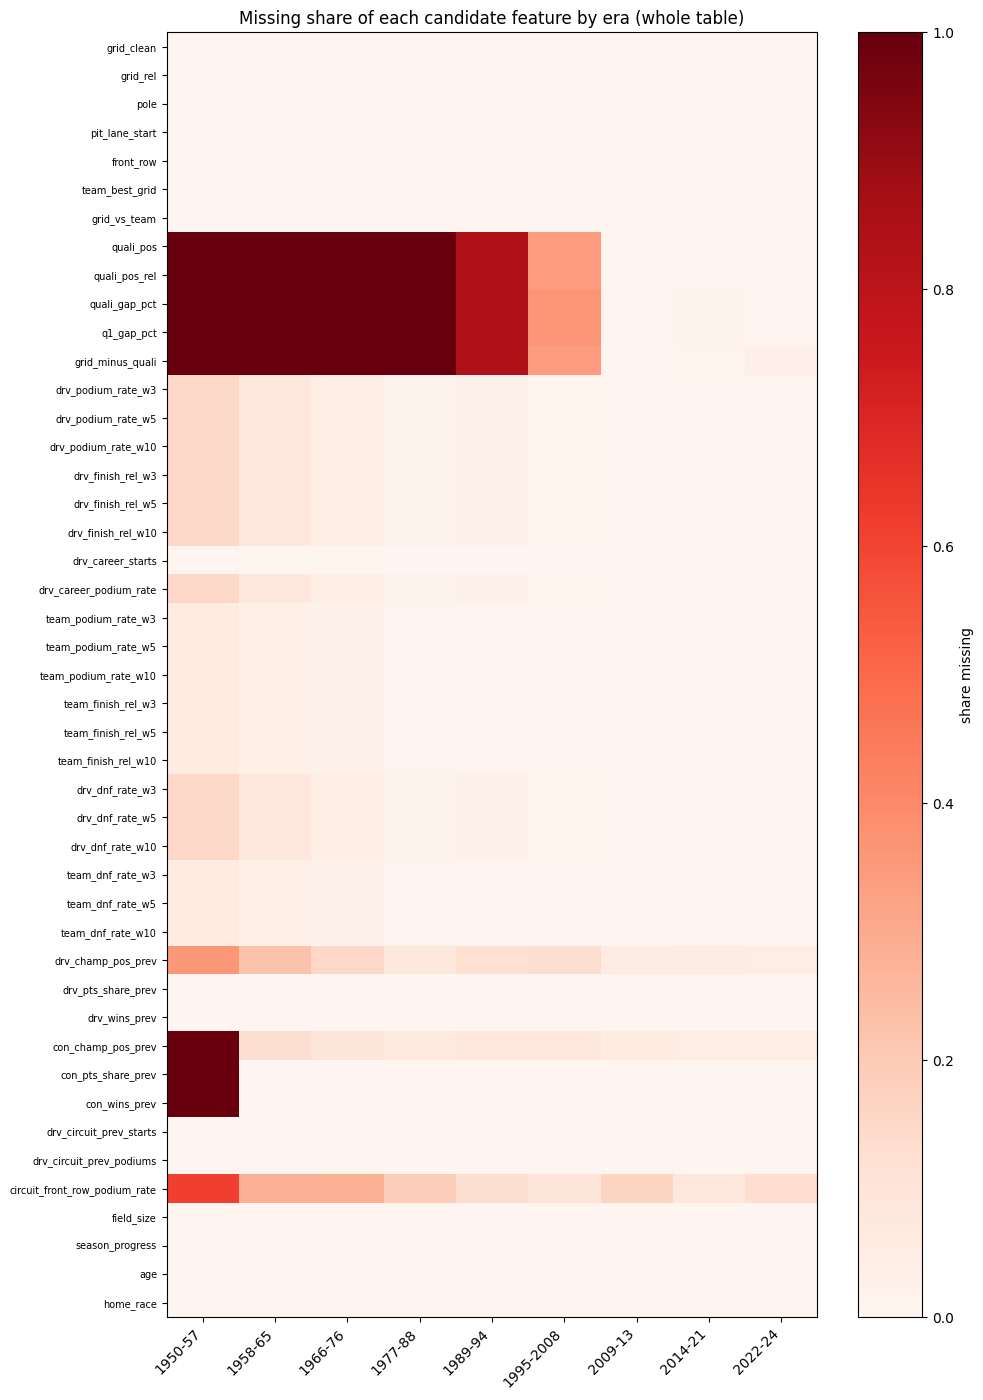

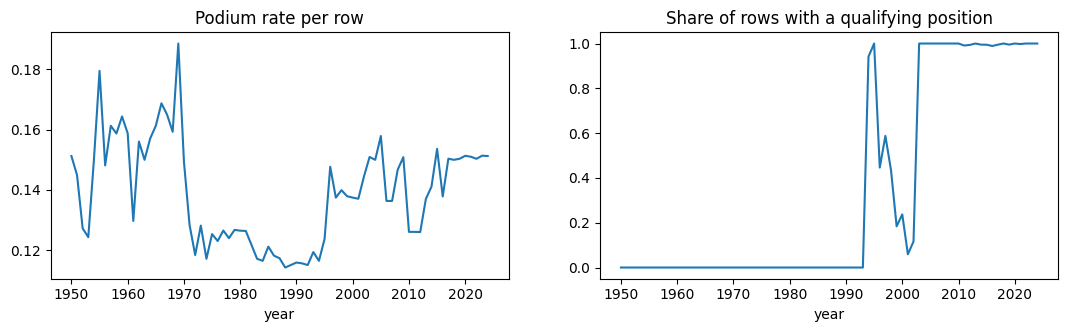

In [9]:
# EDA of the modeling table: how much of each feature exists, per era and per group
ERA_B = ERA_BINS if "ERA_BINS" in globals() else [1949, 1957, 1965, 1976, 1988, 1994, 2008, 2013, 2021, 2100]
ERA_L = ERA_LABELS if "ERA_LABELS" in globals() else ["1950-57", "1958-65", "1966-76", "1977-88", "1989-94", "1995-2008", "2009-13", "2014-21", "2022-24"]
df["era"] = pd.cut(df["year"], bins=ERA_B, labels=ERA_L)

miss = df.groupby("era", observed=True)[ALL_CANDIDATES].apply(lambda g: g.isna().mean()).T
fig, ax = plt.subplots(figsize=(10, 0.28 * len(miss) + 1.5))
im = ax.imshow(miss.to_numpy(dtype=float), aspect="auto", cmap="Reds", vmin=0, vmax=1)
ax.set_yticks(range(len(miss))); ax.set_yticklabels(miss.index, fontsize=7)
ax.set_xticks(range(miss.shape[1])); ax.set_xticklabels(miss.columns, rotation=45, ha="right")
plt.colorbar(im, label="share missing"); ax.set_title("Missing share of each candidate feature by era (whole table)")
plt.tight_layout(); plt.show()

by_year = df.groupby("year").agg(rows=("podium", "size"), podium_rate=("podium", "mean"),
                                 quali_cov=("quali_pos", lambda s: s.notna().mean()))
fig, axes = plt.subplots(1, 2, figsize=(13, 3.2))
by_year["podium_rate"].plot(ax=axes[0], title="Podium rate per row"); by_year["quali_cov"].plot(ax=axes[1], title="Share of rows with a qualifying position")
for ax in axes: add_eras(ax) if "add_eras" in globals() else None
plt.show()

**What this shows.** Qualifying features are missing for whole early eras because the data does not exist. Form and standings are missing only for debutants and season openers.
This missingness carries information, so Part 11 keeps missing-value indicators.

## 9. Train / validation / test split
Split by whole seasons, in time order

| Split | Seasons | Use |
|---|---|---|
| **train** | up to 2019 (from the chosen start year) | fit models |
| **validation** | 2020–2021 | choose features, models, thresholds |
| **test** | 2022 onwards | opened once, for the final score |

Validation is small (about 40 races), so only trust differences that are clearly large. The test seasons are a new rule era, which makes the test harder than a random split. For hyperparameter search inside train, use the walk-forward folds below, not shuffled folds.

In [10]:
#   train <= 2019 | validation 2020-2021 | test >= 2022
LAST_YEAR = int(df["year"].max())
TRAIN_END, VAL_YEARS = 2019, [2020, 2021]
TEST_YEARS = list(range(2022, LAST_YEAR + 1))
df["split"] = np.where(df["year"].isin(TEST_YEARS), "test", np.where(df["year"].isin(VAL_YEARS), "val", "train"))

def assert_no_test(*frames):
    for f in frames:
        assert "test" not in set(f["split"]), "test rows leaked into a model-selection step"

def evaluate(d, p):
    # threshold-free metrics + a race-aware one: of the 3 drivers ranked highest in each race, how many really podiumed?
    p = np.asarray(p, float)
    top3 = d.assign(_p=p).sort_values(["raceId", "_p"], ascending=[True, False]).groupby("raceId").head(3)
    return dict(roc_auc=roc_auc_score(d[TARGET], p), pr_auc=average_precision_score(d[TARGET], p),
                top3_precision=top3[TARGET].mean())

def make_estimator(kind, features, cat_cols=()):
    # exploratory estimators used ONLY to compare feature sets / windows on validation data
    if kind == "lr":
        num = Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=True, keep_empty_features=True)),
                        ("sc", StandardScaler())])
        parts = [("num", num, list(features))]
        if cat_cols:
            parts.append(("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=30), list(cat_cols)))
        return Pipeline([("pre", ColumnTransformer(parts)),
                         ("clf", LogisticRegression(C=1.0, class_weight="balanced", max_iter=3000))])
    return Pipeline([("pre", ColumnTransformer([("num", "passthrough", list(features))])),
                     ("clf", HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=150,
                                                           min_samples_leaf=40, l2_regularization=1.0,
                                                           early_stopping=False, random_state=SEED))])

def fit_eval(train_df, val_df, features, kind, cat_cols=()):
    assert_no_test(train_df, val_df)
    cols = list(features) + list(cat_cols)
    est = make_estimator(kind, features, cat_cols).fit(train_df[cols], train_df[TARGET])
    return evaluate(val_df, est.predict_proba(val_df[cols])[:, 1])

def season_walk_forward(d, n_folds=3):
    # expanding-window folds: train on seasons < s, validate on season s (for hyper-parameter search later)
    yrs = sorted(d["year"].unique())[-n_folds:]
    return [(d.index[d["year"] < s], d.index[d["year"] == s]) for s in yrs]

print("Test seasons:", TEST_YEARS, "| validation seasons:", VAL_YEARS)

Test seasons: [2022, 2023, 2024] | validation seasons: [2020, 2021]


### 9.1 Experiment: where should the training window start?
Form features always use the full history, but training rows can start later. Candidate start years follow rule changes (1996, 2003, 2006 knockout qualifying, 2011 DRS, 2014 hybrid). The start with the best mean validation PR-AUC (two quick models) is used.

,window_start,model,train_rows,roc_auc,pr_auc,top3_precision
0,1950,lr,22441,0.9347,0.7424,0.6838
1,1950,hgb,22441,0.9323,0.7100,0.6923
2,1996,lr,9264,0.9333,0.7153,0.6923
3,1996,hgb,9264,0.9328,0.7235,0.6838
4,2003,lr,6781,0.9317,0.7224,0.6838
5,2003,hgb,6781,0.9381,0.7268,0.6838
6,2006,lr,5742,0.9325,0.7205,0.6923
7,2006,hgb,5742,0.9302,0.7079,0.6838
8,2011,lr,3814,0.9298,0.7264,0.6667
9,2011,hgb,3814,0.9299,0.7196,0.6838


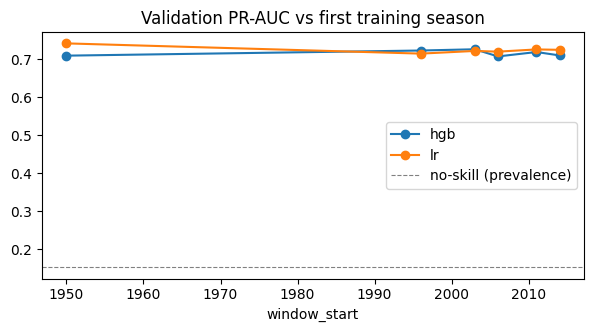

WINDOW_START = 1950 (highest mean validation PR-AUC over the two models)


In [11]:
all_train = df[df["split"] == "train"]; val_all = df[df["split"] == "val"]
# era-motivated candidates (reference document): 1996 qualifying data and lap-time era, 2003 single-lap qualifying,
# 2006 knockout qualifying (Q1/Q2/Q3 times), 2011 DRS + single tyre supplier, 2014 hybrid era
starts = sorted({s for s in [int(df["year"].min()), 1996, 2003, 2006, 2011, 2014] if s <= VAL_YEARS[0] - 4})
rows = []
for s in starts:
    tr = all_train[all_train["year"] >= s]
    for kind in ["lr", "hgb"]:
        rows.append(dict(window_start=s, model=kind, train_rows=len(tr), **fit_eval(tr, val_all, CORE_CANDIDATES, kind)))
win = pd.DataFrame(rows)
display(win.round(4))

piv = win.pivot(index="window_start", columns="model", values="pr_auc")
ax = piv.plot(marker="o", figsize=(7, 3.2), title="Validation PR-AUC vs first training season")
ax.axhline(val_all[TARGET].mean(), color="grey", ls="--", lw=0.8, label="no-skill (prevalence)"); ax.legend(); plt.show()

WINDOW_START = int(piv.mean(axis=1).idxmax())
print(f"WINDOW_START = {WINDOW_START} (highest mean validation PR-AUC over the two models)")

,rows,races,first_season,last_season,podiums,podium_rate
split,,,,,,
train,22441,1007,1950,2019,3021,0.135
val,774,39,2020,2021,117,0.151
test,1351,68,2022,2024,204,0.151


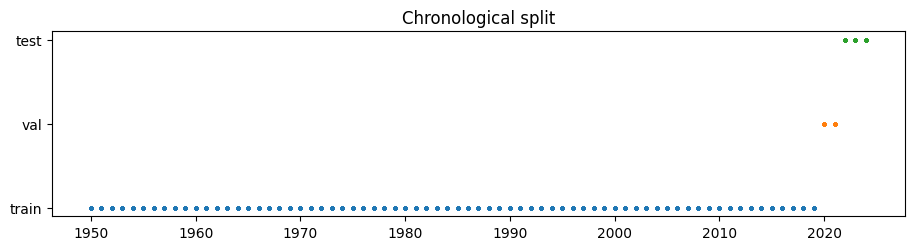

Walk-forward folds inside train (for hyper-parameter search):
  fold 0: train rows 21,203 -> validate on season 2017 (399 rows)
  fold 1: train rows 21,602 -> validate on season 2018 (420 rows)
  fold 2: train rows 22,022 -> validate on season 2019 (419 rows)


In [12]:
mdl = df[df["year"] >= WINDOW_START].reset_index(drop=True)
train = mdl[mdl["split"] == "train"].copy()
val = mdl[mdl["split"] == "val"].copy()
test = mdl[mdl["split"] == "test"].copy()          # NOT used by anything until the final evaluation

summary = (mdl.groupby("split").agg(rows=(TARGET, "size"), races=("raceId", "nunique"),
                                    first_season=("year", "min"), last_season=("year", "max"),
                                    podiums=(TARGET, "sum"), podium_rate=(TARGET, "mean"))
              .loc[["train", "val", "test"]])
display(summary.round(3))

# the three splits are disjoint in races and strictly ordered in time
assert not (set(train["raceId"]) & set(val["raceId"])) and not (set(val["raceId"]) & set(test["raceId"])) \
       and not (set(train["raceId"]) & set(test["raceId"]))
assert train["race_order"].max() < val["race_order"].min() <= val["race_order"].max() < test["race_order"].min()
assert not mdl.duplicated(["raceId", "driverId"]).any()

fig, ax = plt.subplots(figsize=(11, 2.4))
for name, d in [("train", train), ("val", val), ("test", test)]:
    ax.scatter(d["year"], np.full(len(d), {"train": 0, "val": 1, "test": 2}[name]), s=3, alpha=0.3, label=name)
ax.set_yticks([0, 1, 2]); ax.set_yticklabels(["train", "val", "test"]); ax.set_title("Chronological split"); plt.show()

print("Walk-forward folds inside train (for hyper-parameter search):")
for i, (a, b) in enumerate(season_walk_forward(train)):
    print(f"  fold {i}: train rows {len(a):,} -> validate on season {int(train.loc[b, 'year'].iloc[0])} ({len(b)} rows)")

## 10. Feature selection
This part uses **training rows only** (plus validation for the group trials). The test seasons are never opened.

### 10.1 Single-feature signal
ROC-AUC and PR-AUC of each feature alone, with its coverage. The cell after the table checks the document's claim that pole is the strongest single predictor.

,feature,group,coverage,roc_auc,pr_auc,direction
0,quali_pos,qualifying,0.369,0.905,0.594,-
1,quali_pos_rel,qualifying,0.369,0.903,0.599,-
2,grid_clean,grid,1.000,0.883,0.497,-
3,quali_gap_pct,qualifying,0.363,0.881,0.584,-
4,grid_rel,grid,1.000,0.878,0.499,-
5,team_best_grid,grid,1.000,0.858,0.409,-
6,team_podium_rate_w10,constructor_form,0.989,0.840,0.439,+
7,drv_champ_pos_prev,standings,0.876,0.839,0.446,-
8,drv_podium_rate_w10,driver_form,0.970,0.833,0.431,+
9,q1_gap_pct,qualifying,0.363,0.830,0.453,-


Top 5 single features by ROC-AUC: ['quali_pos', 'quali_pos_rel', 'grid_clean', 'quali_gap_pct', 'grid_rel']
  pole        rank 38 of 45 | ROC-AUC 0.595 | PR-AUC 0.238
  grid_clean  rank 3 of 45 | ROC-AUC 0.883 | PR-AUC 0.497
  quali_pos   rank 1 of 45 | ROC-AUC 0.905 | PR-AUC 0.594


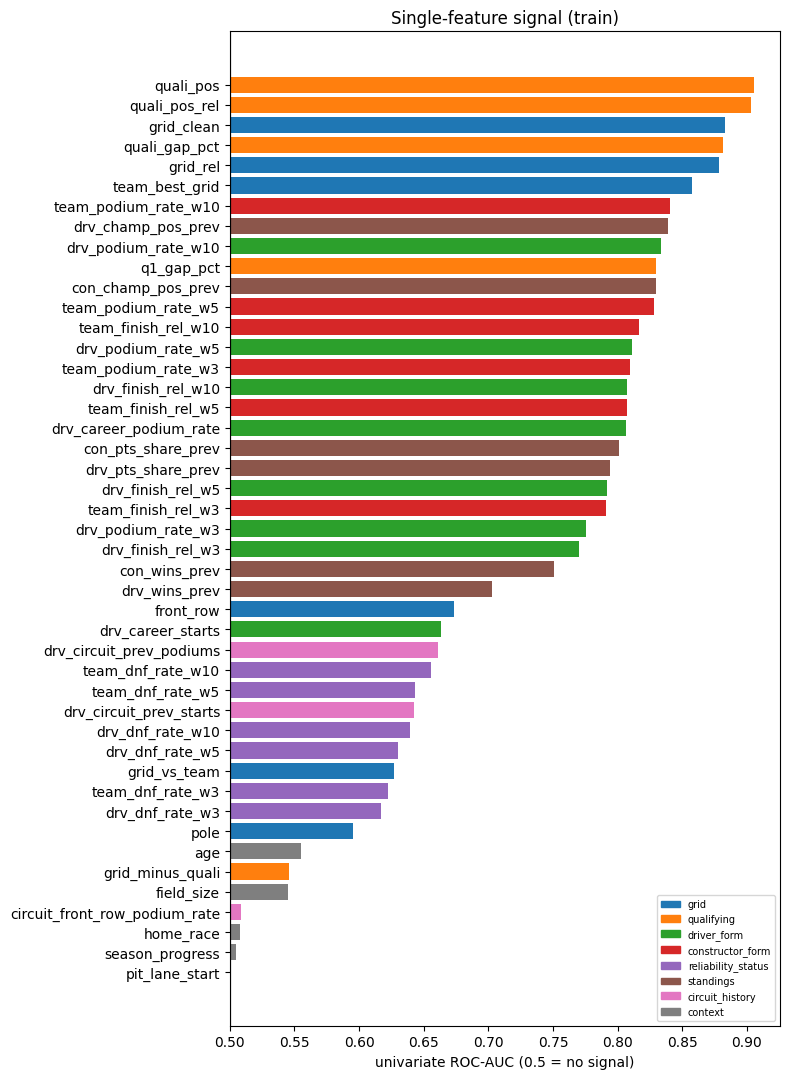

In [13]:
group_of = {f: g for g, fs in CANDIDATE_GROUPS.items() for f in fs}

def uni_auc(d, f):
    m = d[f].notna(); y = d.loc[m, TARGET]
    out = dict(feature=f, group=group_of[f], coverage=m.mean(), roc_auc=np.nan, pr_auc=np.nan, direction="")
    if m.sum() < 50 or y.nunique() < 2 or d.loc[m, f].nunique() < 2:
        return out
    a = roc_auc_score(y, d.loc[m, f]); sgn = 1 if a >= 0.5 else -1
    out.update(roc_auc=max(a, 1 - a), pr_auc=average_precision_score(y, sgn * d.loc[m, f]), direction="+" if sgn > 0 else "-")
    return out

uni = pd.DataFrame([uni_auc(train, f) for f in ALL_CANDIDATES]).sort_values("roc_auc", ascending=False).reset_index(drop=True)
display(uni.round(3))

ranked = uni.dropna(subset=["roc_auc"]).reset_index(drop=True)
print("Top 5 single features by ROC-AUC:", ranked["feature"].head(5).tolist())
for f in ["pole", "grid_clean", "quali_pos"]:
    print(f"  {f:11s} rank {int(ranked.index[ranked['feature'] == f][0]) + 1} of {len(ranked)} | ROC-AUC {ranked.set_index('feature').loc[f, 'roc_auc']:.3f} "
          f"| PR-AUC {ranked.set_index('feature').loc[f, 'pr_auc']:.3f}")
colors = dict(zip(CANDIDATE_GROUPS, plt.cm.tab10.colors))
u = uni.dropna(subset=["roc_auc"]).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 0.22 * len(u) + 1))
ax.barh(u["feature"], u["roc_auc"] - 0.5, left=0.5, color=[colors[g] for g in u["group"]])
ax.axvline(0.5, color="k", lw=0.8); ax.set_xlabel("univariate ROC-AUC (0.5 = no signal)"); ax.set_title("Single-feature signal (train)")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in colors.values()], labels=list(colors), fontsize=7, loc="lower right")
plt.tight_layout(); plt.show()

### 10.2 Podium rate against each feature
Each panel shows the podium rate in 8 equal-count bins of the feature (dashed line = overall rate). A useful feature moves the rate away from the line; a flat panel is evidence against it.

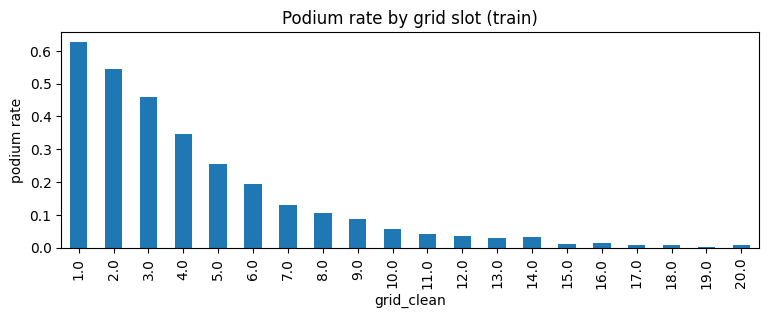

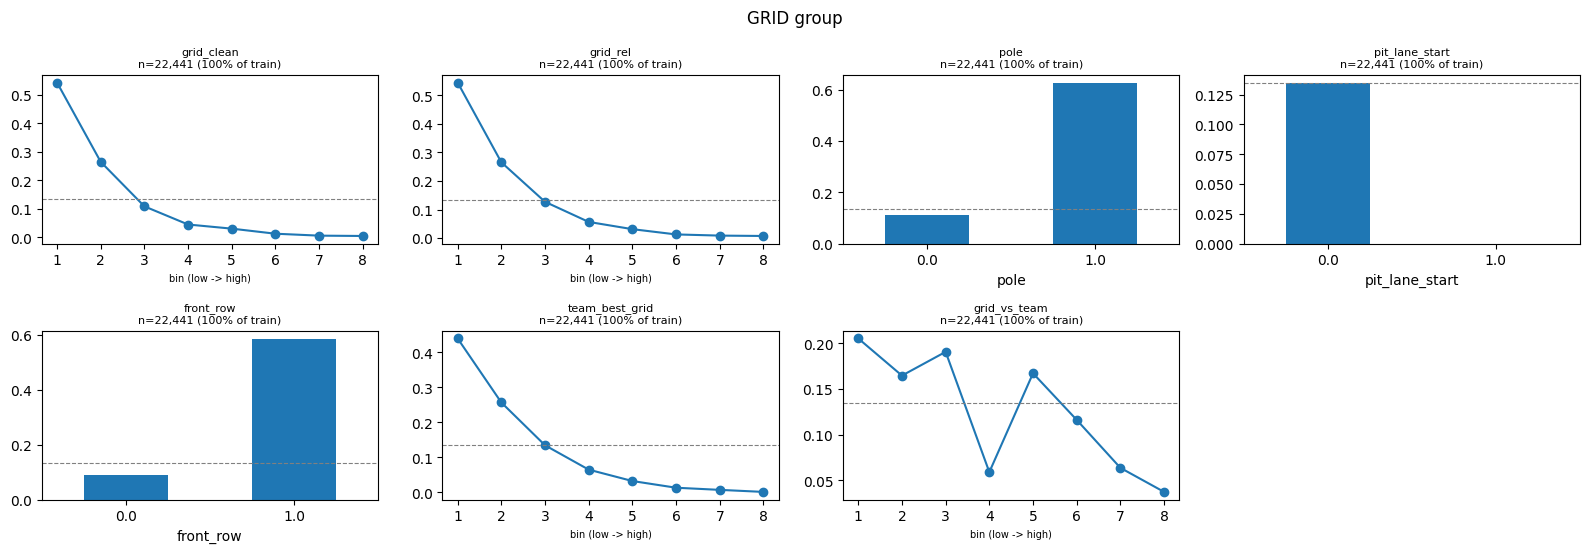

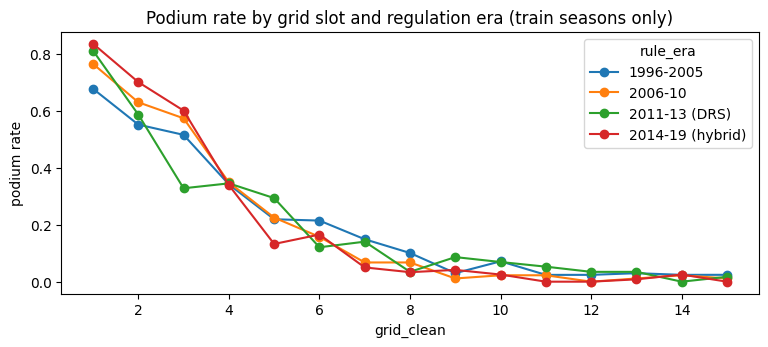

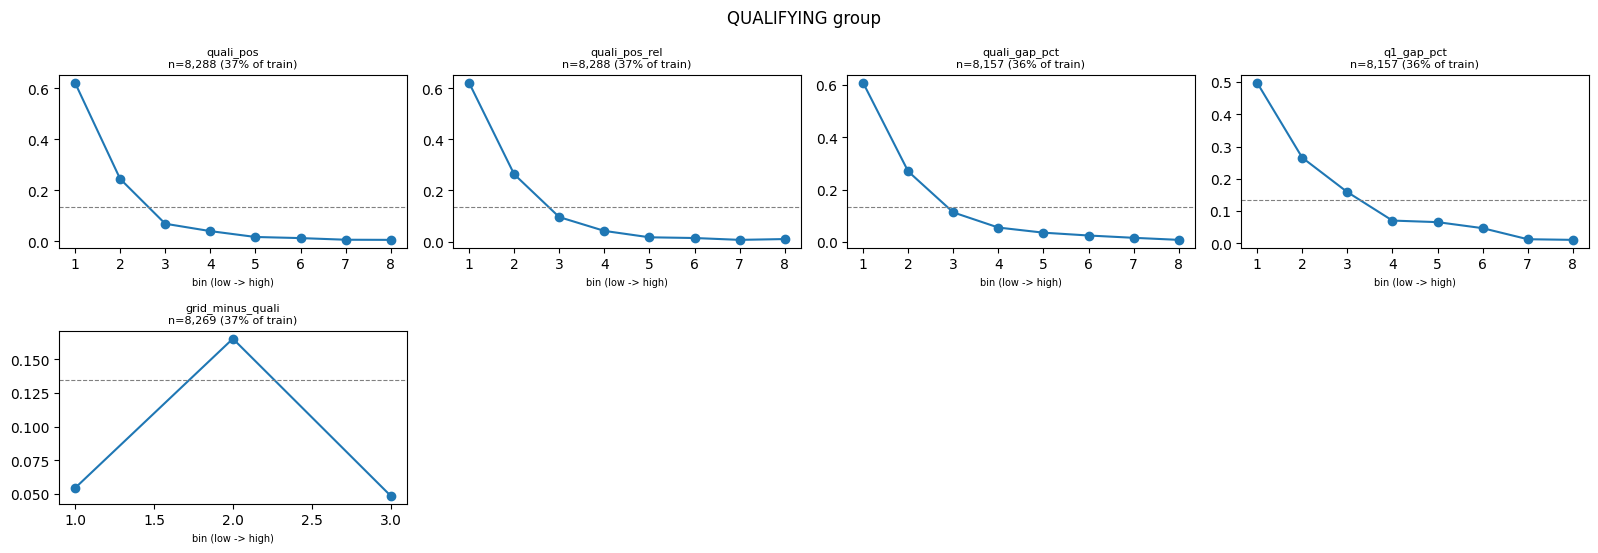

In [14]:
def effect_plot(features, title, q=8, ncols=4):
    features = list(features)
    nrows = math.ceil(len(features) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.8 * nrows)); axes = np.atleast_1d(axes).ravel()
    base = train[TARGET].mean()
    for ax, f in zip(axes, features):
        s = train[[f, TARGET]].dropna()
        if s[f].nunique() <= 2:
            s.groupby(f)[TARGET].mean().plot(kind="bar", ax=ax, rot=0)
        else:
            g = s.groupby(pd.qcut(s[f], q=min(q, s[f].nunique()), duplicates="drop"), observed=True)[TARGET].mean()
            ax.plot(range(1, len(g) + 1), g.values, marker="o"); ax.set_xlabel("bin (low -> high)", fontsize=7)
        ax.axhline(base, color="grey", ls="--", lw=0.8)
        ax.set_title(f"{f}\nn={len(s):,} ({len(s)/len(train):.0%} of train)", fontsize=8)
    for ax in axes[len(features):]: ax.axis("off")
    fig.suptitle(title); plt.tight_layout(); plt.show()

# starting slot: the classic picture, one bar per grid slot
slot = train[train["grid_clean"].between(1, 20)].groupby("grid_clean")[TARGET].mean()
ax = slot.plot(kind="bar", figsize=(9, 2.8), title="Podium rate by grid slot (train)"); ax.set_ylabel("podium rate"); plt.show()
effect_plot(CANDIDATE_GROUPS["grid"], "GRID group")

# Reference document: DRS (2011) made grid slightly less decisive and early reliability was far lower. Does the grid->podium curve differ by era?
tt = df[df["split"] == "train"].copy()
tt["rule_era"] = pd.cut(tt["year"], [1995, 2005, 2010, 2013, 2019], labels=["1996-2005", "2006-10", "2011-13 (DRS)", "2014-19 (hybrid)"])
curve = tt[tt["grid_clean"].between(1, 15)].groupby(["rule_era", "grid_clean"], observed=True)[TARGET].mean().unstack(0)
ax = curve.plot(marker="o", figsize=(9, 3.4), title="Podium rate by grid slot and regulation era (train seasons only)")
ax.set_ylabel("podium rate"); plt.show()
effect_plot(CANDIDATE_GROUPS["qualifying"], "QUALIFYING group")

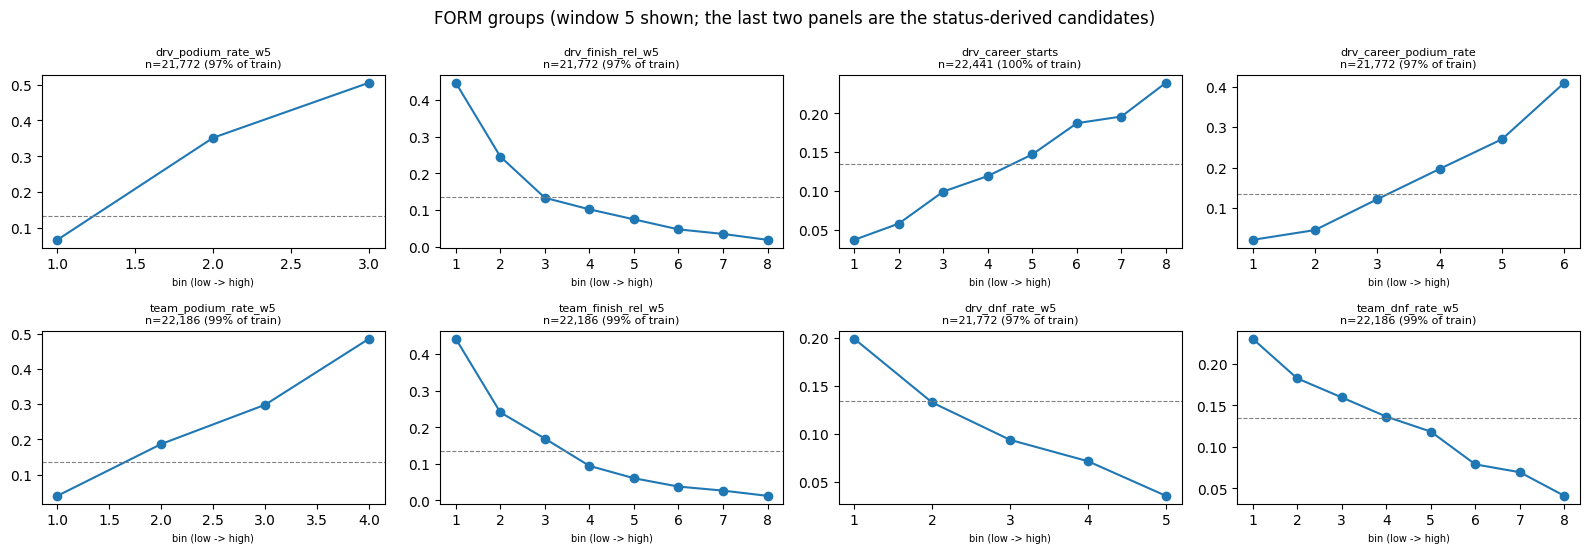

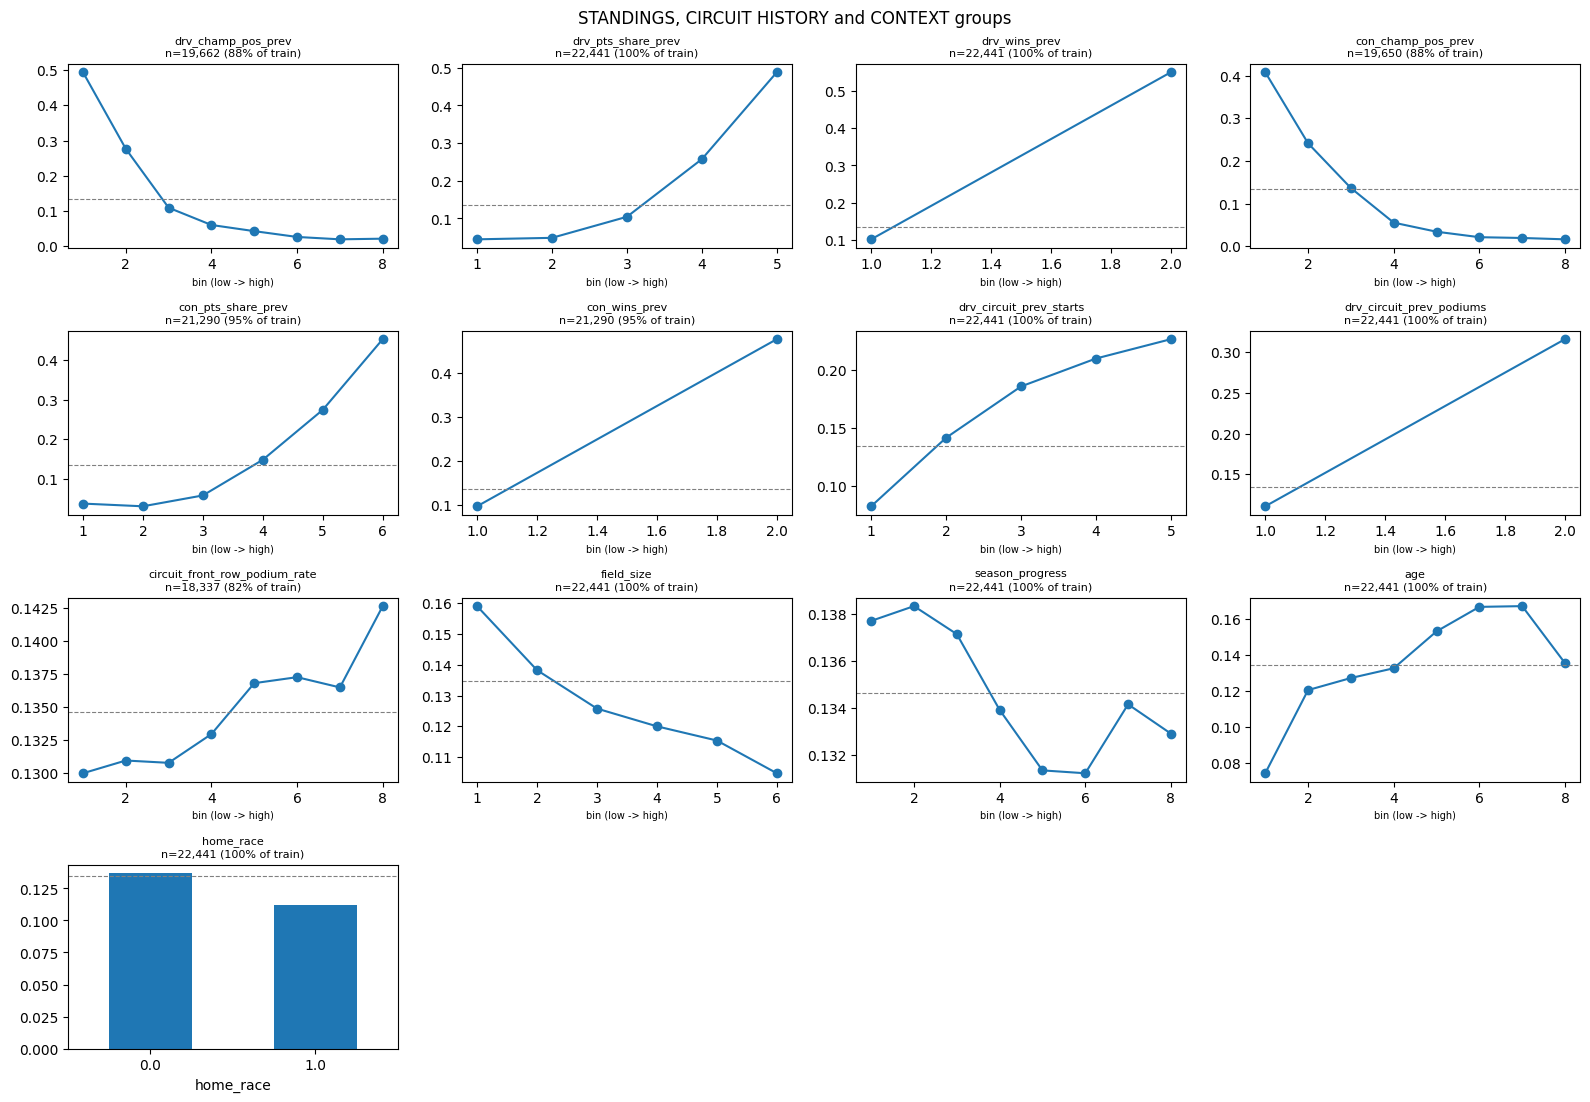

In [15]:
effect_plot([f for g in ["driver_form", "constructor_form", "reliability_status"] for f in CANDIDATE_GROUPS[g]
             if f.endswith("_w5") or "career" in f], "FORM groups (window 5 shown; the last two panels are the status-derived candidates)")
effect_plot(CANDIDATE_GROUPS["standings"] + CANDIDATE_GROUPS["circuit_history"] + CANDIDATE_GROUPS["context"],
            "STANDINGS, CIRCUIT HISTORY and CONTEXT groups")

mean          size      
home_race    0.0    1.0    0.0   1.0
grid_band                           
1-3        0.544  0.544   2801   215
4-6        0.265  0.269   2800   212
7-10       0.098  0.071   3681   322
11+        0.017  0.011  11286  1111

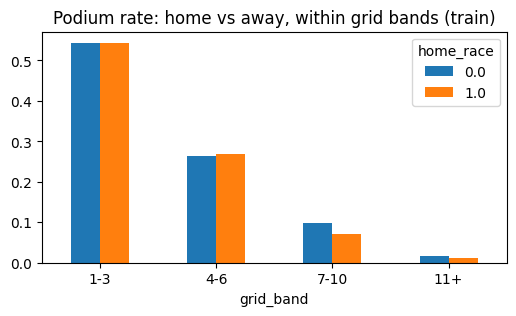

In [16]:
# Home race (brief Q2) controlled for starting position: compare podium rates within grid bands
t = train.copy(); t["grid_band"] = pd.cut(t["grid_clean"], [0, 3, 6, 10, 30], labels=["1-3", "4-6", "7-10", "11+"])
hb = t.groupby(["grid_band", "home_race"], observed=True)[TARGET].agg(["mean", "size"]).unstack("home_race")
display(hb.round(3))
hb["mean"].plot(kind="bar", figsize=(6, 3), rot=0, title="Podium rate: home vs away, within grid bands (train)"); plt.show()


### 10.3 Choosing the form window (3, 5 or 10 races)
For each form feature we take the longest window within 0.003 AUC of the best, using training data.

,w3,w5,w10
drv_podium_rate,0.7754,0.8108,0.8335
drv_finish_rel,0.7698,0.7919,0.8075
team_podium_rate,0.8096,0.8285,0.8404
team_finish_rel,0.7907,0.8073,0.8168
drv_dnf_rate,0.6169,0.6304,0.6395
team_dnf_rate,0.6224,0.6429,0.6558


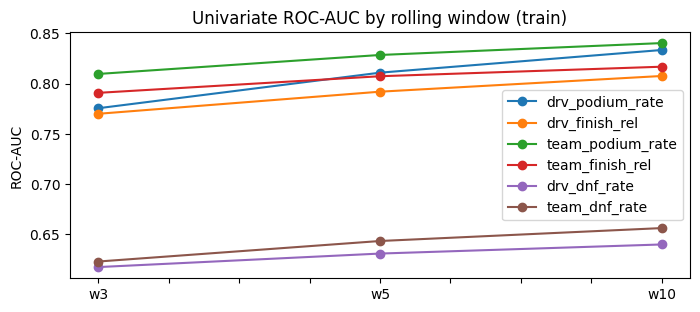

Chosen windows: {'drv_podium_rate': 10, 'drv_finish_rel': 10, 'team_podium_rate': 10, 'team_finish_rel': 10, 'drv_dnf_rate': 10, 'team_dnf_rate': 10}


In [17]:
fam_auc = pd.DataFrame({fam: {w: uni.set_index("feature").loc[f"{fam}_w{w}", "roc_auc"] for w in FORM_WINDOWS} for fam in ALL_FAMILIES}).T
fam_auc.columns = [f"w{w}" for w in FORM_WINDOWS]
display(fam_auc.round(4))
ax = fam_auc.T.plot(marker="o", figsize=(8, 3.2), title="Univariate ROC-AUC by rolling window (train)"); ax.set_ylabel("ROC-AUC"); plt.show()

BEST_W = {}
for fam in ALL_FAMILIES:
    s = fam_auc.loc[fam]
    BEST_W[fam] = max(w for w in FORM_WINDOWS if s[f"w{w}"] >= s.max() - 0.003)
print("Chosen windows:", BEST_W)

ACTIVE_GROUPS = {g: list(fs) for g, fs in CANDIDATE_GROUPS.items()}
pick = lambda fams: [f"{fam}_w{BEST_W[fam]}" for fam in fams]
ACTIVE_GROUPS["driver_form"] = pick(["drv_podium_rate", "drv_finish_rel"]) + ["drv_career_starts", "drv_career_podium_rate"]
ACTIVE_GROUPS["constructor_form"] = pick(["team_podium_rate", "team_finish_rel"])
ACTIVE_GROUPS["reliability_status"] = pick(STATUS_FAMILIES)
STATUS_CANDIDATES = list(ACTIVE_GROUPS["reliability_status"])          # kept for the 10.7 trial
if not INCLUDE_STATUS_FORM:
    ACTIVE_GROUPS.pop("reliability_status")                              # reference document: status is not a feature

### 10.4 Redundant features
Spearman correlation between features. For pairs with |ρ| ≥ 0.95 the weaker feature is dropped. `grid_clean` and `quali_pos` are protected: the project needs grid and qualifying position as separate variables.

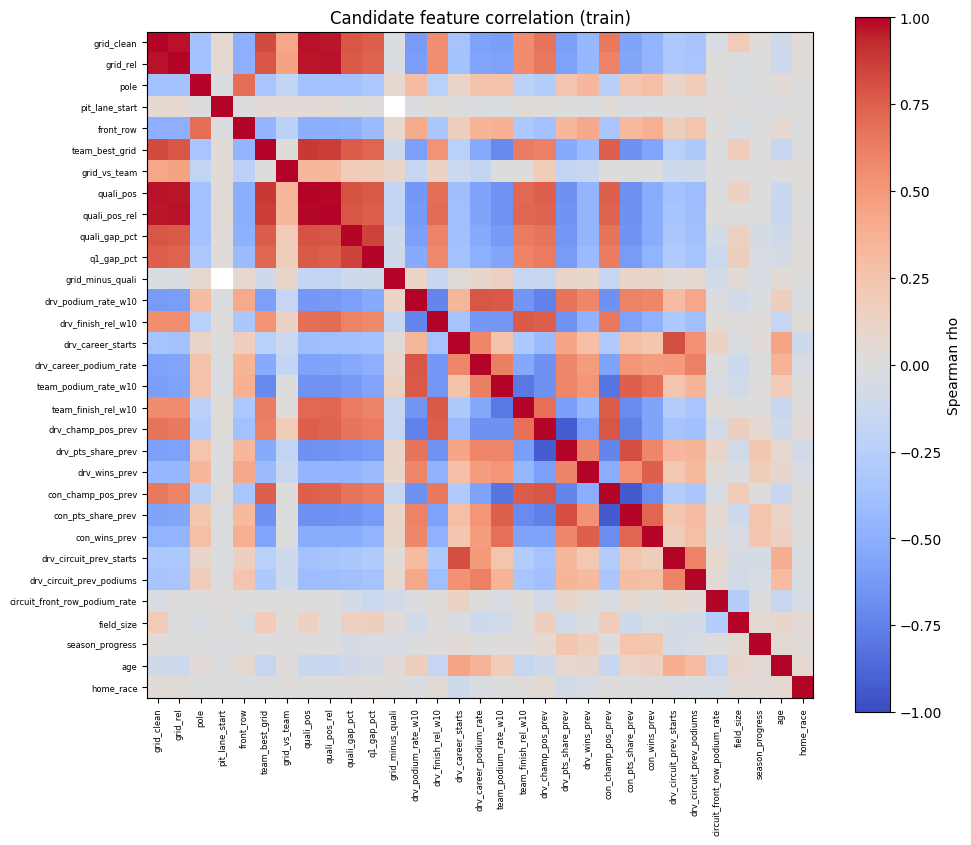

rho(grid_clean, grid_rel) = +0.970  -> drop grid_rel
rho(grid_clean, quali_pos) = +0.976  -> both protected, both kept
rho(grid_clean, quali_pos_rel) = +0.962  -> drop quali_pos_rel
Dropped as redundant: ['grid_rel', 'quali_pos_rel']


In [18]:
cand = [f for fs in ACTIVE_GROUPS.values() for f in fs]
corr = train[cand].corr(method="spearman")
fig, ax = plt.subplots(figsize=(10, 8.5))
im = ax.imshow(corr.to_numpy(), cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(cand))); ax.set_xticklabels(cand, rotation=90, fontsize=6)
ax.set_yticks(range(len(cand))); ax.set_yticklabels(cand, fontsize=6)
plt.colorbar(im, label="Spearman rho"); ax.set_title("Candidate feature correlation (train)"); plt.tight_layout(); plt.show()

auc_of = uni.set_index("feature")["roc_auc"]
PROTECTED = {"grid_clean", "quali_pos"}      # the two core signals: Q1 needs grid and qualifying kept as DIFFERENT variables
dropped, THR = [], 0.95
for i, a in enumerate(cand):
    for b in cand[i + 1:]:
        if a in dropped or b in dropped: continue
        if abs(corr.loc[a, b]) >= THR:
            if a in PROTECTED and b in PROTECTED:
                print(f"rho({a}, {b}) = {corr.loc[a, b]:+.3f}  -> both protected, both kept"); continue
            loser = b if a in PROTECTED else a if b in PROTECTED else (a if auc_of.get(a, 0) < auc_of.get(b, 0) else b)
            dropped.append(loser)
            print(f"rho({a}, {b}) = {corr.loc[a, b]:+.3f}  -> drop {loser}")
print("Dropped as redundant:", dropped or "none")
ACTIVE_GROUPS = {g: [f for f in fs if f not in dropped] for g, fs in ACTIVE_GROUPS.items()}

### 10.5 Mutual information
Also detects non-straight-line relationships with the target (training data).

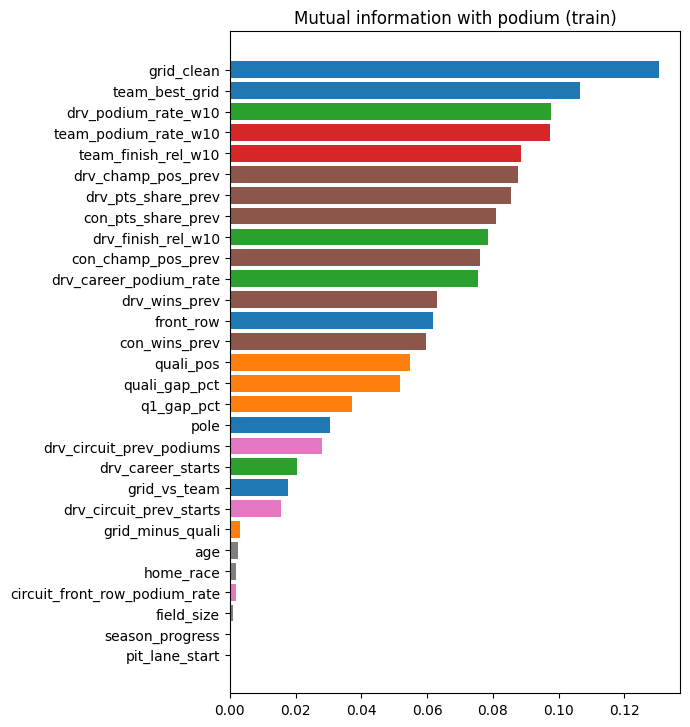

In [19]:
feats_now = [f for fs in ACTIVE_GROUPS.values() for f in fs]
Xi = SimpleImputer(strategy="median", keep_empty_features=True).fit_transform(train[feats_now])
mi = pd.Series(mutual_info_classif(Xi, train[TARGET], random_state=SEED), index=feats_now).sort_values()
fig, ax = plt.subplots(figsize=(7, 0.22 * len(mi) + 1))
ax.barh(mi.index, mi.values, color=[colors[group_of[f]] for f in mi.index]); ax.set_title("Mutual information with podium (train)")
plt.tight_layout(); plt.show()

### 10.6 Add one feature group at a time (validation)
Starts from a baseline (logistic regression on the starting slot alone). Each row adds one group and scores it with a linear model and a gradient-boosting model.

,step,model,n_features,roc_auc,pr_auc,top3_precision,d_pr_auc
0,baseline: grid_clean only,lr,1,0.9101,0.6478,0.7009,NaN
1,baseline: grid_clean only,hgb,1,0.9096,0.6477,0.7009,NaN
2,+ grid,lr,6,0.9167,0.6654,0.7009,0.0176
3,+ grid,hgb,6,0.9135,0.6613,0.7094,0.0136
4,+ qualifying,lr,10,0.9272,0.6662,0.7094,0.0008
5,+ qualifying,hgb,10,0.9287,0.6834,0.7009,0.0221
6,+ driver_form,lr,14,0.9336,0.7382,0.6923,0.0720
7,+ driver_form,hgb,14,0.9312,0.7252,0.7094,0.0417
8,+ constructor_form,lr,16,0.9336,0.7270,0.6838,-0.0112
9,+ constructor_form,hgb,16,0.9312,0.7191,0.7009,-0.0061


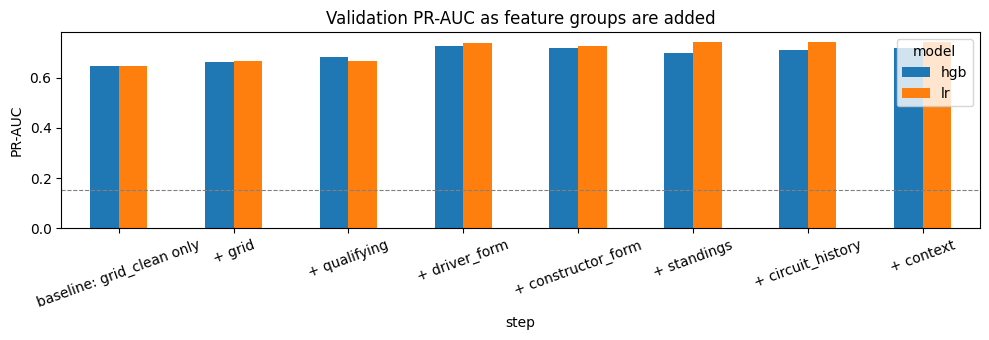

In [20]:
order = ["grid", "qualifying", "driver_form", "constructor_form", "standings", "circuit_history", "context"]
order = [g for g in order if g in ACTIVE_GROUPS]
steps = [("baseline: grid_clean only", ["grid_clean"])]
cum = []
for g in order:
    cum = cum + ACTIVE_GROUPS[g]
    steps.append((f"+ {g}", list(cum)))

rows = []
for name, fs in steps:
    for kind in ["lr", "hgb"]:
        rows.append(dict(step=name, model=kind, n_features=len(fs), **fit_eval(train, val, fs, kind)))
inc = pd.DataFrame(rows)
for m in ["lr", "hgb"]:
    inc.loc[inc["model"] == m, "d_pr_auc"] = inc.loc[inc["model"] == m, "pr_auc"].diff()
display(inc.round(4))

piv = inc.pivot(index="step", columns="model", values="pr_auc").loc[[s for s, _ in steps]]
ax = piv.plot(kind="bar", figsize=(10, 3.5), rot=20, title="Validation PR-AUC as feature groups are added")
ax.axhline(val[TARGET].mean(), color="grey", ls="--", lw=0.8); ax.set_ylabel("PR-AUC"); plt.tight_layout(); plt.show()

**How to read it.** A group is justified if PR-AUC and top-3 precision rise when it is added. Quote these numbers in the report.

### 10.7 Candidates left out, and what that costs
Each excluded candidate is tested against the final set on validation; the last column is the PR-AUC change versus the reference row.

In [21]:
fs_all = [f for g in order for f in ACTIVE_GROUPS[g]]
tr_c, va_c = train.copy(), val.copy()
for d in (tr_c, va_c):
    d["year_num"] = d["year"].astype(float)
    d["drs_era"] = (d["year"] >= 2011).astype(float)          # regulation-era flags from the reference document
    d["hybrid_era"] = (d["year"] >= 2014).astype(float)
variants = [("final feature set (reference)", fs_all, ()),
            ("+ raw year (numeric)", fs_all + ["year_num"], ()),
            ("+ regulation-era flags (DRS 2011, hybrid 2014)", fs_all + ["drs_era", "hybrid_era"], ()),
            ("+ status-derived retirement rates (reliability_status)", fs_all + [f for f in STATUS_CANDIDATES if f not in fs_all], ()),
            ("+ constructorId one-hot (LR only)", fs_all, ("constructorId",))]
rows = []
for name, fs, cat in variants:
    for kind in (["lr"] if cat else ["lr", "hgb"]):
        rows.append(dict(variant=name, model=kind, **fit_eval(tr_c, va_c, fs, kind, cat_cols=cat)))
rej = pd.DataFrame(rows)
for m in ["lr", "hgb"]:
    ref = rej[(rej["model"] == m) & rej["variant"].str.startswith("final")]["pr_auc"].iloc[0]
    rej.loc[rej["model"] == m, "d_pr_auc_vs_final"] = rej.loc[rej["model"] == m, "pr_auc"] - ref
display(rej.round(4))

# coverage of the data sources we did not turn into features (share of rows whose race exists in the table: train, validation)
cov = {t: (train["raceId"].isin(tables[t]["raceId"].astype(int)).mean(), val["raceId"].isin(tables[t]["raceId"].astype(int)).mean())
       for t in ["sprint_results", "lap_times", "pit_stops"] if t in tables}
print("Share of rows whose race exists in the source table (train, validation):", {k: (round(a, 3), round(b, 3)) for k, (a, b) in cov.items()})
print("Circuit latitude/longitude: static labels of a circuit, redundant with the circuit-history features and easy to memorise.")

,variant,model,roc_auc,pr_auc,top3_precision,d_pr_auc_vs_final
0,final feature set (reference),lr,0.9353,0.7430,0.6838,0.0000
1,final feature set (reference),hgb,0.9319,0.7171,0.6923,0.0000
2,+ raw year (numeric),lr,0.9365,0.7487,0.6838,0.0057
3,+ raw year (numeric),hgb,0.9310,0.7182,0.6923,0.0011
4,"+ regulation-era flags (DRS 2011, hybrid 2014)",lr,0.9355,0.7438,0.6838,0.0008
5,"+ regulation-era flags (DRS 2011, hybrid 2014)",hgb,0.9315,0.7202,0.6838,0.0032
6,+ status-derived retirement rates (reliability...,lr,0.9351,0.7394,0.6838,-0.0036
7,+ status-derived retirement rates (reliability...,hgb,0.9318,0.7250,0.6838,0.0079
8,+ constructorId one-hot (LR only),lr,0.9317,0.7376,0.6923,-0.0054


Share of rows whose race exists in the source table (train, validation): {'sprint_results': (np.float64(0.0), np.float64(0.076)), 'lap_times': (np.float64(0.413), np.float64(1.0)), 'pit_stops': (np.float64(0.17), np.float64(0.974))}
Circuit latitude/longitude: static labels of a circuit, redundant with the circuit-history features and easy to memorise.


**Why each is excluded**
- **Raw `year`:** test seasons lie outside the training range, so models would have to extrapolate.
- **Era flags (DRS 2011, hybrid 2014):** only worth adding if the gain clearly exceeds validation noise; by default the training window handles era effects.
- **Status-derived retirement rates:** the document says status is post-race and for Q3 only, and it mixes mechanical failures with accidents. If the cost above is large, discuss switching `INCLUDE_STATUS_FORM = True` (it only uses earlier races).
- **`constructorId` one-hot:** team ids change and unseen teams appear in test; team level is already in constructor form.
- **Sprint:** only from 2021, after the training period.
- **Lap times, pit stops, fastest lap, safety car, tyres:** post-race; never features.

### 10.8 Final feature list and dictionary
The dictionary below (definition, source tables, why valid at the cutoff) goes into the report.

In [22]:
FEATURE_GROUPS = {g: list(fs) for g, fs in ACTIVE_GROUPS.items() if fs}
FEATURES = [f for fs in FEATURE_GROUPS.values() for f in fs]
BINARY = [f for f in BINARY_FEATURES if f in FEATURES]
CONTINUOUS = [f for f in FEATURES if f not in BINARY]

DEFS = {  # base name -> (definition, why it is known at the cutoff, source tables)
 "grid_clean": ("Starting slot; pit-lane start (grid 0) mapped to the back row", "grid is set after qualifying (incl. penalties)", "results"),
 "grid_rel": ("grid_clean / number of starters", "grid and starters list known at the start", "results"),
 "pit_lane_start": ("1 if the driver starts from the pit lane / no slot recorded", "known when the grid is set", "results"),
 "front_row": ("1 if grid_clean <= 2", "derived from the grid", "results"),
 "team_best_grid": ("Best grid slot of the driver's team in this race", "grid of both cars known", "results"),
 "grid_vs_team": ("grid_clean minus the team's mean grid in this race", "grid known", "results"),
 "quali_pos": ("Qualifying classification", "qualifying ends before the cutoff", "qualifying"),
 "quali_pos_rel": ("quali_pos / number of starters", "qualifying known", "qualifying, results"),
 "q1_gap_pct": ("% slower than the fastest Q1 time of the session", "Q1 times known after qualifying", "qualifying"),
 "quali_gap_pct": ("% slower than the fastest time of the LAST qualifying session the driver reached (Q3, else Q2, else Q1)", "qualifying times known after qualifying", "qualifying"),
 "pole": ("1 if the driver starts from pole (grid_clean == 1)", "grid known", "results"),
 "grid_minus_quali": ("grid - qualifying position (penalty signal)", "both known at the cutoff", "results, qualifying"),
 "drv_podium_rate": ("Driver's podium rate in his previous w races", "past races only: shift(1) then rolling", "results"),
 "drv_finish_rel": ("Driver's mean finishing position / field size, previous w races", "past races only", "results"),
 "drv_dnf_rate": ("Driver's retirement rate (status not Finished / +n Laps / Lapped; DSQ excluded), previous w races", "previous races only; status-derived (candidate, off by default)", "results, status"),
 "team_podium_rate": ("Team's podium rate per car, previous w races of the constructor", "past races only", "results"),
 "team_finish_rel": ("Team's mean relative finish, previous w races", "past races only", "results"),
 "team_dnf_rate": ("Team's retirement rate, previous w races", "previous races only; status-derived (candidate, off by default)", "results, status"),
 "drv_career_starts": ("Number of earlier races of the driver in the table", "count of past rows", "results"),
 "drv_career_podium_rate": ("Podium rate over all earlier races of the driver", "expanding mean, current race excluded", "results"),
 "drv_champ_pos_prev": ("Driver championship position after the previous round", "strictly earlier round of the same season", "driver_standings, races"),
 "drv_pts_share_prev": ("Driver points / leader's points after the previous round", "strictly earlier round", "driver_standings, races"),
 "drv_wins_prev": ("Driver wins after the previous round", "strictly earlier round", "driver_standings, races"),
 "con_champ_pos_prev": ("Constructor championship position after the previous round", "strictly earlier round", "constructor_standings, races"),
 "con_pts_share_prev": ("Constructor points / leader's points after the previous round", "strictly earlier round", "constructor_standings, races"),
 "con_wins_prev": ("Constructor wins after the previous round", "strictly earlier round", "constructor_standings, races"),
 "drv_circuit_prev_starts": ("Driver's earlier starts at this circuit", "count of past rows", "results, races"),
 "drv_circuit_prev_podiums": ("Driver's earlier podiums at this circuit", "cumulative sum minus current row", "results, races"),
 "circuit_front_row_podium_rate": ("Share of front-row starts in the last 8 races at this circuit that ended on the podium (>= 3 past races)", "past races only", "results, races"),
 "field_size": ("Number of starters", "starters known on the grid", "results"),
 "season_progress": ("round / rounds in the season", "calendar is published in advance", "races"),
 "age": ("Driver age in years on race day", "date of birth and race date known", "drivers, races"),
 "home_race": ("1 if the driver's nationality maps to the circuit's country", "static", "drivers, circuits, nationality_country"),
}
def base_name(f): return f.rsplit("_w", 1)[0] if f.rsplit("_w", 1)[-1].isdigit() else f
missing_defs = [f for f in FEATURES if base_name(f) not in DEFS]
assert not missing_defs, f"add dictionary entries for {missing_defs}"
feature_dictionary = pd.DataFrame([dict(feature=f, group=group_of[f], definition=DEFS[base_name(f)][0],
                                        valid_at_cutoff_because=DEFS[base_name(f)][1], sources=DEFS[base_name(f)][2],
                                        coverage_train=train[f].notna().mean()) for f in FEATURES])
print(f"{len(FEATURES)} features selected ({len(BINARY)} binary, {len(CONTINUOUS)} continuous)")
feature_dictionary.round(3)

29 features selected (4 binary, 25 continuous)


,feature,group,definition,valid_at_cutoff_because,sources,coverage_train
0,grid_clean,grid,Starting slot; pit-lane start (grid 0) mapped ...,grid is set after qualifying (incl. penalties),results,1.000
1,pole,grid,1 if the driver starts from pole (grid_clean =...,grid known,results,1.000
2,pit_lane_start,grid,1 if the driver starts from the pit lane / no ...,known when the grid is set,results,1.000
3,front_row,grid,1 if grid_clean <= 2,derived from the grid,results,1.000
4,team_best_grid,grid,Best grid slot of the driver's team in this race,grid of both cars known,results,1.000
5,grid_vs_team,grid,grid_clean minus the team's mean grid in this ...,grid known,results,1.000
6,quali_pos,qualifying,Qualifying classification,qualifying ends before the cutoff,qualifying,0.369
7,quali_gap_pct,qualifying,% slower than the fastest time of the LAST qua...,qualifying times known after qualifying,qualifying,0.363
8,q1_gap_pct,qualifying,% slower than the fastest Q1 time of the session,Q1 times known after qualifying,qualifying,0.363
9,grid_minus_quali,qualifying,grid - qualifying position (penalty signal),both known at the cutoff,"results, qualifying",0.368


## 11. Preprocessing
### 11.1 Missing values
Missing data is structural (no data, or no earlier race yet). Rules, all learned on training rows only:
- continuous features: median imputation plus a missing-indicator column
- binary flags: most frequent value
- linear model and neural network only: clip at the 1st/99th percentile, then standardise
- no categorical features remain, so no encoding is needed

In [23]:
miss_tr = train[FEATURES].isna().mean().sort_values(ascending=False)
display(miss_tr[miss_tr > 0].round(3).to_frame("share missing (train)").T)
tr_era = pd.cut(train["year"], ERA_B, labels=ERA_L)
m_era = train.groupby(tr_era, observed=True)[[f for f in FEATURES if miss_tr[f] > 0]].apply(lambda g: g.isna().mean()).T
display(m_era.round(2))

,q1_gap_pct,quali_gap_pct,grid_minus_quali,quali_pos,circuit_front_row_podium_rate,con_champ_pos_prev,drv_champ_pos_prev,con_wins_prev,con_pts_share_prev,drv_podium_rate_w10,drv_finish_rel_w10,drv_career_podium_rate,team_finish_rel_w10,team_podium_rate_w10
share missing (train),0.637,0.637,0.632,0.631,0.183,0.124,0.124,0.051,0.051,0.03,0.03,0.03,0.011,0.011


year,1950-57,1958-65,1966-76,1977-88,1989-94,1995-2008,2009-13,2014-21
quali_pos,1.00,1.00,1.00,1.00,0.84,0.35,0.00,0.01
quali_gap_pct,1.00,1.00,1.00,1.00,0.84,0.36,0.01,0.02
q1_gap_pct,1.00,1.00,1.00,1.00,0.84,0.36,0.01,0.02
grid_minus_quali,1.00,1.00,1.00,1.00,0.84,0.35,0.00,0.01
drv_podium_rate_w10,0.15,0.08,0.04,0.02,0.02,0.01,0.01,0.01
drv_finish_rel_w10,0.15,0.08,0.04,0.02,0.02,0.01,0.01,0.01
drv_career_podium_rate,0.15,0.08,0.04,0.02,0.02,0.01,0.01,0.01
team_podium_rate_w10,0.05,0.04,0.02,0.00,0.00,0.01,0.01,0.00
team_finish_rel_w10,0.05,0.04,0.02,0.00,0.00,0.01,0.01,0.00
drv_champ_pos_prev,0.36,0.22,0.15,0.08,0.12,0.13,0.06,0.05


In [ ]:
class QuantileClipper(BaseEstimator, TransformerMixin):
    """Winsorise each column at quantiles LEARNED ON THE TRAINING DATA (NaN stays NaN)."""
    def __init__(self, lower=0.01, upper=0.99): self.lower, self.upper = lower, upper
    def fit(self, X, y=None):
        X = np.asarray(X, float)
        self.lo_ = np.nanquantile(X, self.lower, axis=0); self.hi_ = np.nanquantile(X, self.upper, axis=0); return self
    def transform(self, X): return np.clip(np.asarray(X, float), self.lo_, self.hi_)
    def get_feature_names_out(self, input_features=None): return np.asarray(input_features, dtype=object)


linear preprocessor: 29 input columns -> 43 output columns (continuous + missing indicators + binary); NaN left: 0


### 11.2 Effect on the data
Left: raw training values. Right: after imputing, clipping and scaling. The table gives range, skew and missing share before and after.

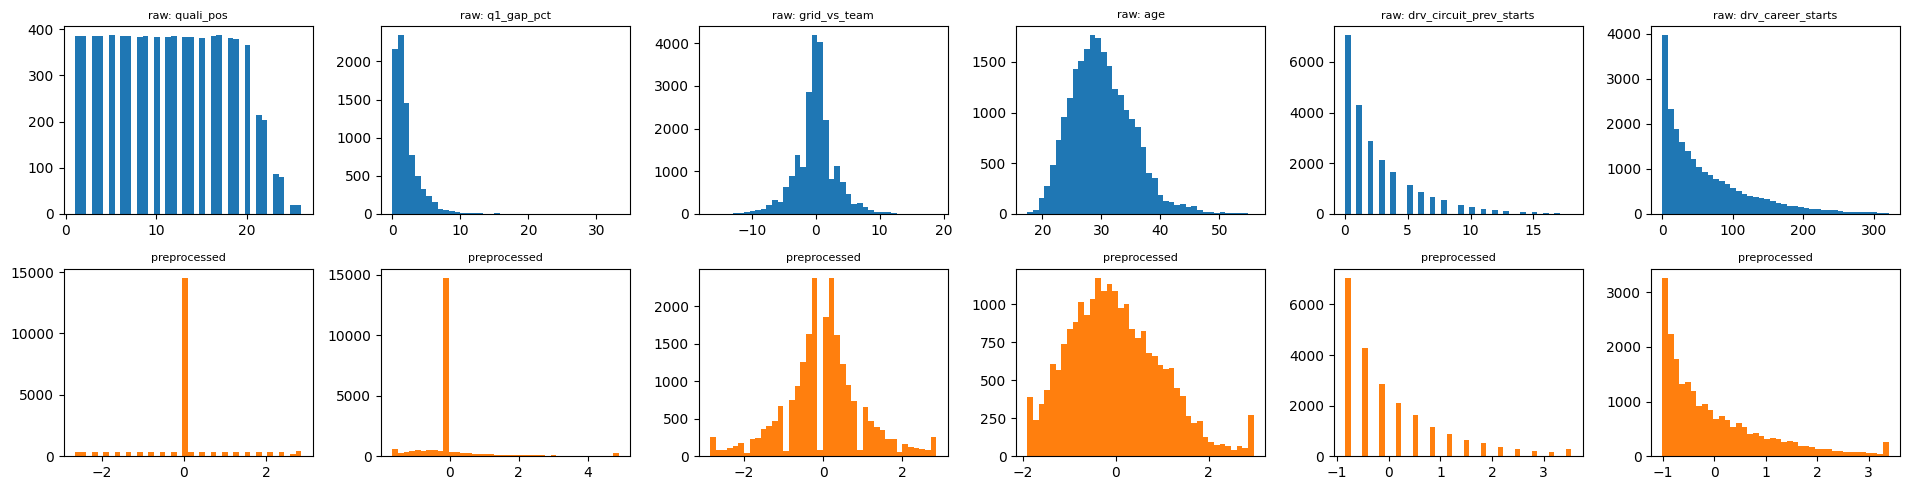

mean     std     min      max   skew  \
quali_pos               before  11.345   6.359   1.000   26.000  0.082   
                        after    0.000   1.000  -2.650    2.855  0.195   
q1_gap_pct              before   2.019   1.994   0.000   33.285  3.400   
                        after   -0.000   1.000  -1.662    4.891  2.688   
grid_vs_team            before  -0.000   3.091 -16.545   18.833  0.054   
                        after    0.000   1.000  -2.849    2.851  0.015   
age                     before  30.044   5.184  17.454   55.797  0.639   
                        after   -0.000   1.000  -1.898    2.968  0.501   
drv_circuit_prev_starts before   2.537   3.030   0.000   18.000  1.647   
                        after   -0.000   1.000  -0.850    3.535  1.508   
drv_career_starts       before  61.425  61.577   0.000  321.000  1.419   
                        after    0.000   1.000  -1.007    3.387  1.340   

                                missing  
quali_pos               before    0.631  
                        after     0.000  
q1_gap_pct              before    0.637  
                        after     0.000  
grid_vs_team            before    0.000  
                        after     0.000  
age                     before    0.000  
                        after     0.000  
drv_circuit_prev_starts before    0.000  
                        after     0.000  
drv_career_starts       before    0.000  
                        after     0.000

In [25]:
show = [f for f in ["quali_pos", "q1_gap_pct", "grid_vs_team", "age", "drv_circuit_prev_starts", "drv_career_starts",
                    "drv_podium_rate_w%d" % BEST_W["drv_podium_rate"], "con_pts_share_prev"] if f in CONTINUOUS][:6]
pre_s = make_preprocessor("linear").fit(train[FEATURES])
Xs = pd.DataFrame(pre_s.transform(train[FEATURES])[:, :len(CONTINUOUS)], columns=CONTINUOUS)
fig, axes = plt.subplots(2, len(show), figsize=(3.2 * len(show), 5))
for j, f in enumerate(show):
    axes[0, j].hist(train[f].dropna(), bins=40); axes[0, j].set_title(f"raw: {f}", fontsize=8)
    axes[1, j].hist(Xs[f], bins=40, color="tab:orange"); axes[1, j].set_title("preprocessed", fontsize=8)
plt.tight_layout(); plt.show()

stat = lambda s: pd.Series(dict(mean=s.mean(), std=s.std(), min=s.min(), max=s.max(), skew=s.skew(), missing=s.isna().mean()))
effect = pd.concat({f: pd.concat({"before": stat(train[f]), "after": stat(Xs[f])}, axis=1).T for f in show})
display(effect.round(3))

### 11.3 Preprocessing-order experiments (logistic regression, validation)
**P1:** statistics fitted on train only (correct) versus train + validation (leaky). Shows how far the learned medians move.
**P2:** five step orders: impute→scale, scale→impute, impute with indicators→scale, impute→clip→scale, clip→impute→scale.

,fit_on,roc_auc,pr_auc,top3_precision
0,train only (correct),0.9342,0.7339,0.6838
1,train + validation (leaky),0.9346,0.7382,0.6838


Largest shift in a learned median (in train standard deviations):


,median_train,median_train+val,std_train,std_train+val,median_shift
quali_gap_pct,1.828,1.783,0.971,0.983,0.046
q1_gap_pct,1.497,1.458,0.998,1.011,0.039
season_progress,0.556,0.550,0.288,0.288,0.019
drv_career_starts,41.000,42.000,60.764,63.053,0.016
age,29.544,29.481,5.064,5.097,0.012


,roc_auc,pr_auc,top3_precision
order,,,
A impute -> scale,0.9318,0.7332,0.6838
B scale -> impute,0.9318,0.7333,0.6838
C impute+indicator -> scale,0.9353,0.7430,0.6838
D impute -> clip -> scale,0.9302,0.7234,0.6838
E clip -> impute -> scale,0.9306,0.7253,0.6838


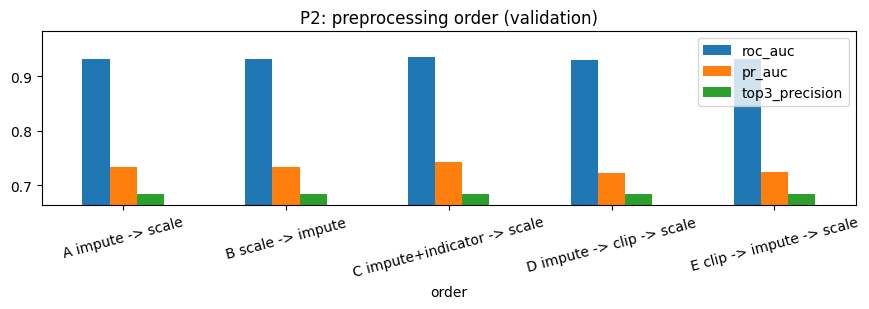

Best order by validation PR-AUC: C impute+indicator -> scale


In [26]:
def lr_score(pre, fit_frame, train_df, val_df, feats):
    assert_no_test(fit_frame, train_df, val_df)
    p = clone(pre).fit(fit_frame[feats])
    clf = LogisticRegression(C=1.0, class_weight="balanced", max_iter=3000).fit(p.transform(train_df[feats]), train_df[TARGET])
    return evaluate(val_df, clf.predict_proba(p.transform(val_df[feats]))[:, 1]), p

# ---- P1 -------------------------------------------------------------------------------------
pre = make_preprocessor("linear")
s_correct, p_c = lr_score(pre, train, train, val, FEATURES)
s_leaky, p_l = lr_score(pre, pd.concat([train, val]), train, val, FEATURES)
med_c = p_c.named_transformers_["cont"].named_steps["imp"].statistics_
med_l = p_l.named_transformers_["cont"].named_steps["imp"].statistics_
sd_c = p_c.named_transformers_["cont"].named_steps["sc"].scale_
sd_l = p_l.named_transformers_["cont"].named_steps["sc"].scale_
p1 = pd.DataFrame([dict(fit_on="train only (correct)", **s_correct), dict(fit_on="train + validation (leaky)", **s_leaky)])
display(p1.round(4))
shift = pd.DataFrame({"median_train": med_c, "median_train+val": med_l, "std_train": sd_c[:len(med_c)], "std_train+val": sd_l[:len(med_c)]}, index=CONTINUOUS)
shift["median_shift"] = (shift["median_train+val"] - shift["median_train"]).abs() / (shift["std_train"] + 1e-9)
print("Largest shift in a learned median (in train standard deviations):")
display(shift.sort_values("median_shift", ascending=False).head(5).round(3))

# ---- P2 -------------------------------------------------------------------------------------
def variant(name):
    imp = lambda ind: SimpleImputer(strategy="median", add_indicator=ind, keep_empty_features=True)
    steps = {"A impute -> scale": [("imp", imp(False)), ("sc", StandardScaler())],
             "B scale -> impute": [("sc", StandardScaler()), ("imp", imp(False))],
             "C impute+indicator -> scale": [("imp", imp(True)), ("sc", StandardScaler())],
             "D impute -> clip -> scale": [("imp", imp(False)), ("clip", QuantileClipper()), ("sc", StandardScaler())],
             "E clip -> impute -> scale": [("clip", QuantileClipper()), ("imp", imp(False)), ("sc", StandardScaler())]}[name]
    return Pipeline(steps)

rows = []
for name in ["A impute -> scale", "B scale -> impute", "C impute+indicator -> scale", "D impute -> clip -> scale", "E clip -> impute -> scale"]:
    sc, _ = lr_score(variant(name), train, train, val, FEATURES)
    rows.append(dict(order=name, **sc))
p2 = pd.DataFrame(rows).set_index("order"); display(p2.round(4))
ax = p2[["roc_auc", "pr_auc", "top3_precision"]].plot(kind="bar", figsize=(9, 3.2), rot=15, title="P2: preprocessing order (validation)")
ax.set_ylim(p2[["roc_auc", "pr_auc", "top3_precision"]].min().min() - 0.02, None); plt.tight_layout(); plt.show()
print("Best order by validation PR-AUC:", p2["pr_auc"].idxmax())

**Reading P1/P2.** P1 usually shifts statistics only slightly, but it is wrong in principle because validation data influences the transformation. For P2, small differences are expected for a regularised linear model; report the printed numbers.
`make_preprocessor("linear")` is handed to the modeling section.

## 12. Final checks, saving and hand-off

In [27]:
# ---- final assertions ---------------------------------------------------------------------------------
assert set(FEATURES) <= set(mdl.columns) and len(FEATURES) == len(set(FEATURES))
assert not set(FEATURES) & set(ID_COLS + [TARGET, "split"])
assert not mdl.duplicated(["raceId", "driverId"]).any()
assert set(train["year"]) & set(TEST_YEARS) == set() and set(val["year"]) & set(TEST_YEARS) == set()
assert train["race_order"].max() < val["race_order"].min() and val["race_order"].max() < test["race_order"].min()
assert not train[FEATURES].isna().all().any(), "a selected feature is empty in training data"
assert np.isfinite(make_preprocessor("linear").fit(train[FEATURES]).transform(test[FEATURES])).all()   # the pipeline runs on unseen rows (features only)
print(f"OK: {len(FEATURES)} features | train {len(train):,} | val {len(val):,} | test {len(test):,} | "
      f"window {WINDOW_START}-{LAST_YEAR} | test seasons {TEST_YEARS}")

# ---- save for teammates / the modeling section ---------------------------------------------------------
OUT_FE = OUT if "OUT" in globals() else "clean/"
os.makedirs(OUT_FE, exist_ok=True)
config = dict(features=FEATURES, binary=BINARY, continuous=CONTINUOUS, groups=FEATURE_GROUPS, target=TARGET,
              window_start=WINDOW_START, include_status_form=INCLUDE_STATUS_FORM, train_years=sorted(map(int, train["year"].unique())),
              val_years=VAL_YEARS, test_years=TEST_YEARS, form_windows=BEST_W, seed=SEED)
json.dump(config, open(OUT_FE + "feature_config.json", "w"), indent=2)
feature_dictionary.to_csv(OUT_FE + "feature_dictionary.csv", index=False)
try:
    mdl.drop(columns=["era"], errors="ignore").to_parquet(OUT_FE + "modeling_table.parquet", index=False)
except Exception:
    mdl.drop(columns=["era"], errors="ignore").to_csv(OUT_FE + "modeling_table.csv", index=False)
print("Saved modeling table, feature_config.json and feature_dictionary.csv to", OUT_FE)

OK: 29 features | train 22,441 | val 774 | test 1,351 | window 1950-2024 | test seasons [2022, 2023, 2024]
Saved modeling table, feature_config.json and feature_dictionary.csv to clean/


### Handed to the modeling, ablation and XAI sections
| Object | What it is |
|---|---|
| `train`, `val`, `test` | chronological splits (`test` stays closed until the end) |
| `FEATURES`, `CONTINUOUS`, `BINARY` | final feature list and types |
| `FEATURE_GROUPS` | `{group: [features]}`, for the ablation |
| `make_preprocessor(kind)` | `"linear"` (logistic regression, NN), `"tree"`, `"native"` (HistGradientBoosting etc.) |
| `evaluate(df, p)` | ROC-AUC, PR-AUC, top-3 precision per race (add F1 at a threshold chosen on train/val) |
| `season_walk_forward(train)` | time-ordered folds for hyperparameter search |
| `feature_dictionary` | feature definitions for the report |
| `build_modeling_table(tables)` | reuse for the inference function |

**Limitations for the report:** patchy qualifying data before 2003, test era differs from most training years, team renames reset form, retirement rates mix causes.